In [ ]:
# ── Configuração do ambiente (Colab ou local) ───────────────────────────────
import sys, os, urllib.request
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Instalar dependências extras (xgboost e lightgbm costumam não estar no Colab)
    os.system("pip install -q xgboost lightgbm")

    # Baixar datasets pré-processados do GitHub (~56 MB)
    # Muito mais rápido do que os ZIPs originais do INEP (1,8 GB no total)
    _REPO_RAW = "https://raw.githubusercontent.com/vdms/mvp-ml-analytics-enem-rio/main/outputs/"
    _DATASETS = [
        "enem_rj_results_2022_2024.csv.gz",
        "enem_rj_profiles_2022_2024.csv.gz",
    ]
    os.makedirs("outputs", exist_ok=True)
    for _fname in _DATASETS:
        _dest = Path("outputs") / _fname
        if not _dest.exists():
            print(f"Baixando {_fname}...")
            urllib.request.urlretrieve(_REPO_RAW + _fname, _dest)
            print(f"  OK — {_dest.stat().st_size / 1e6:.1f} MB")


# MVP Machine Learning & Analytics - ENEM Rio/RJ 2022-2024

Este notebook é um relatório técnico executável. Ele testa se variáveis socioeducacionais, escolares e contextuais ajudam a prever alto desempenho em Matemática no ENEM/RJ e se parte desse padrão permanece útil em 2024.

A entrega combina dois experimentos complementares. O Modelo A responde à pergunta socioeducacional individual em 2022-2023. O Modelo B responde à pergunta de robustez temporal em 2024 usando variáveis comparáveis e agregados municipais. Os experimentos não são uma competição direta entre algoritmos.


## Contexto e motivação

O ENEM é uma avaliação nacional de grande escala e permite investigar desigualdades educacionais com dados públicos. O foco aqui não é usar notas ou respostas para prever a própria nota, mas testar o quanto características disponíveis antes ou fora do resultado da prova carregam sinal preditivo.

Essa escolha torna o MVP relevante para uma discussão educacional: desempenho alto não é tratado apenas como número, mas como fenômeno associado a trajetória escolar, perfil socioeconômico e contexto territorial.


## Definição do problema

**Problema:** classificar participantes do ENEM/RJ com alto desempenho em Matemática.

**Target:** `target_desempenho_alto_mt = 1` quando `NU_NOTA_MT` é maior ou igual ao percentil 75 calculado apenas no treino do respectivo experimento.

**Por que é Machine Learning:** há uma variável-alvo observada, múltiplos atributos explicativos e avaliação em dados não vistos. Como as classes são desbalanceadas, o F1-score é a métrica principal, com accuracy, precision, recall, ROC-AUC e matriz de confusão como métricas complementares.


## Hipóteses do Estudo

**H1:** variáveis socioeducacionais e escolares possuem capacidade preditiva relevante para identificar estudantes com alto desempenho em Matemática no ENEM.

**H2:** parte dos padrões aprendidos a partir dos dados de 2022-2023 permanece estável quando avaliada em dados de 2024.

**H3:** modelos supervisionados devem superar um baseline ingênuo tanto na avaliação convencional quanto na avaliação temporal.

As hipóteses são testáveis por comparação com `DummyClassifier`, avaliação em dados não vistos, F1-score, ROC-AUC, matriz de confusão e teste externo em 2024.


## Fonte dos dados e reprodutibilidade

Fonte oficial: [Microdados do ENEM - INEP](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem).

O notebook baixa automaticamente os ZIPs oficiais caso eles não existam em `data/raw/`, o que permite execução pública sem upload manual, login, token ou chave de API. Os microdados brutos não devem ser versionados; apenas artefatos resumidos e bases derivadas leves são salvos em `artifacts/` e `outputs/`.


## Ambiente, bibliotecas e constantes

Esta célula centraliza imports, diretórios, seeds, URLs oficiais e listas de variáveis. As constantes deixam a execução rastreável e reduzem decisões escondidas no código.


In [1]:
from __future__ import annotations

import ast
import csv
import json
import os
import re
import time
import urllib.request
import zipfile
from pathlib import Path

_CURRENT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_MPLCONFIGDIR = _CURRENT_ROOT / "outputs" / ".matplotlib"
_MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPLCONFIGDIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
ARTIFACTS = PROJECT_ROOT / "artifacts"
OUTPUTS = PROJECT_ROOT / "outputs"
REVIEWS = PROJECT_ROOT / "docs" / "reviews"

for directory in [DATA_RAW, ARTIFACTS, OUTPUTS, REVIEWS]:
    directory.mkdir(parents=True, exist_ok=True)

EXPECTED_YEARS = {2022, 2023, 2024}
TRAIN_YEARS = {2022, 2023}
EXTERNAL_TEST_YEAR = 2024
RECORTE_UF = "RJ"
TARGET_SCORE_COLUMN = "NU_NOTA_MT"
TARGET_COLUMN = "target_desempenho_alto_mt"
TARGET_QUANTILE = 0.75
CHUNKSIZE = 200_000
MAX_TRAIN_ROWS_FOR_MODELING = 60_000
DOWNLOAD_IF_MISSING = True

ENEM_DOWNLOAD_URLS = {
    2022: "https://download.inep.gov.br/microdados/microdados_enem_2022.zip",
    2023: "https://download.inep.gov.br/microdados/microdados_enem_2023.zip",
    2024: "https://download.inep.gov.br/microdados/microdados_enem_2024.zip",
}

QUESTIONARIO_COLUMNS_2022_2023 = [f"Q{i:03d}" for i in range(1, 26)]
QUESTIONARIO_COLUMNS_2024 = [f"Q{i:03d}" for i in range(1, 24)]
PROFILE_COLUMNS = [
    "TP_FAIXA_ETARIA", "TP_SEXO", "TP_ESTADO_CIVIL", "TP_COR_RACA", "TP_NACIONALIDADE",
    "TP_ST_CONCLUSAO", "TP_ANO_CONCLUIU", "TP_ESCOLA", "TP_ENSINO", "IN_TREINEIRO",
]
SCHOOL_COLUMNS = [
    "CO_MUNICIPIO_ESC", "NO_MUNICIPIO_ESC", "CO_UF_ESC", "SG_UF_ESC",
    "TP_DEPENDENCIA_ADM_ESC", "TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC",
]
PROVA_COLUMNS = ["CO_MUNICIPIO_PROVA", "NO_MUNICIPIO_PROVA", "CO_UF_PROVA", "SG_UF_PROVA"]
PRESENCE_COLUMNS = ["TP_PRESENCA_CN", "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT"]
SCORE_COLUMNS = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]
REDACAO_COMP_COLUMNS = [f"NU_NOTA_COMP{i}" for i in range(1, 6)]
LEAKAGE_PREFIXES = ("NU_NOTA", "TX_RESPOSTAS", "TX_GABARITO", "CO_PROVA")
AGGREGATE_PROFILE_COLUMNS = ["Q006", "TP_COR_RACA", "TP_SEXO", "TP_FAIXA_ETARIA", "IN_TREINEIRO", "TP_ST_CONCLUSAO", "TP_ENSINO"]

REQUESTED_2022_2023_COLUMNS = (
    ["NU_INSCRICAO", "NU_ANO"] + PROFILE_COLUMNS + SCHOOL_COLUMNS + PROVA_COLUMNS +
    PRESENCE_COLUMNS + SCORE_COLUMNS + REDACAO_COMP_COLUMNS + QUESTIONARIO_COLUMNS_2022_2023
)
REQUESTED_2024_RESULT_COLUMNS = ["NU_ANO"] + SCHOOL_COLUMNS + PROVA_COLUMNS + PRESENCE_COLUMNS + SCORE_COLUMNS + REDACAO_COMP_COLUMNS
REQUESTED_2024_PARTICIPANT_COLUMNS = ["NU_INSCRICAO", "NU_ANO"] + [c for c in PROFILE_COLUMNS if c != "TP_ESCOLA"] + PROVA_COLUMNS + QUESTIONARIO_COLUMNS_2024

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False})

assert EXPECTED_YEARS == set(ENEM_DOWNLOAD_URLS)
assert TRAIN_YEARS.isdisjoint({EXTERNAL_TEST_YEAR})


## Funções de leitura, download e validação

As funções abaixo localizam os ZIPs oficiais, fazem download se necessário, escolhem o CSV correto em cada ano e leem os arquivos em chunks. A leitura em chunks é necessária porque os microdados são grandes.


In [3]:
def find_enem_files(raw_dir: Path = DATA_RAW) -> list[Path]:
    """Retorna os arquivos brutos locais do ENEM ignorando marcadores vazios."""
    files = sorted(raw_dir.glob("*.zip")) + sorted(raw_dir.glob("*.csv"))
    return [path for path in files if path.name != ".gitkeep"]


In [4]:
def infer_year_from_name(path: Path) -> int | None:
    """Extrai o ano do ENEM a partir do nome de um arquivo."""
    match = re.search(r"20\d{2}", path.name)
    return int(match.group(0)) if match else None


In [5]:
def years_available_locally(files: list[Path]) -> set[int]:
    """Lista os anos que já possuem arquivo local disponível."""
    return {year for path in files if (year := infer_year_from_name(path)) is not None}


In [6]:
def download_file(url: str, destination: Path) -> None:
    """Baixa um arquivo remoto para o destino informado com escrita temporária segura."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    temp_destination = destination.with_suffix(destination.suffix + ".partial")
    print(f"Baixando {url} -> {destination.relative_to(PROJECT_ROOT)}")
    with urllib.request.urlopen(url) as response, temp_destination.open("wb") as out_file:
        total = int(response.headers.get("Content-Length", "0"))
        downloaded = 0
        next_report = 0
        while True:
            chunk = response.read(1024 * 1024)
            if not chunk:
                break
            out_file.write(chunk)
            downloaded += len(chunk)
            if total and downloaded >= next_report:
                pct = downloaded / total * 100
                print(f"  {pct:5.1f}% ({downloaded / (1024 ** 2):.1f} MB)")
                next_report += max(total // 10, 1)
    temp_destination.replace(destination)


In [7]:
def ensure_enem_files_available() -> list[Path]:
    """Garante que os arquivos dos anos esperados existam localmente ou sejam baixados."""
    files = find_enem_files()
    missing_years = sorted(EXPECTED_YEARS - years_available_locally(files))
    if missing_years and DOWNLOAD_IF_MISSING:
        for year in missing_years:
            destination = DATA_RAW / f"microdados_enem_{year}.zip"
            if not destination.exists():
                download_file(ENEM_DOWNLOAD_URLS[year], destination)
        files = find_enem_files()
        missing_years = sorted(EXPECTED_YEARS - years_available_locally(files))
    if missing_years:
        raise FileNotFoundError(f"Arquivos ausentes para os anos {missing_years}.")
    return sorted([path for path in files if infer_year_from_name(path) in EXPECTED_YEARS], key=lambda p: infer_year_from_name(p) or 0)


In [8]:
def list_csv_members(zip_path: Path) -> list[str]:
    """Lista os arquivos CSV internos de um ZIP de microdados."""
    with zipfile.ZipFile(zip_path) as zf:
        return [name for name in zf.namelist() if name.lower().endswith(".csv")]


In [9]:
def select_csv_member(zip_path: Path, kind: str) -> str:
    """Seleciona o CSV interno apropriado para microdados, resultados ou participantes."""
    members = list_csv_members(zip_path)
    year = infer_year_from_name(zip_path)
    if kind == "microdados":
        candidates = [m for m in members if "microdados" in Path(m).name.lower()]
    elif kind == "resultados":
        candidates = [m for m in members if "resultados" in Path(m).name.lower()]
        if not candidates and year in {2022, 2023}:
            candidates = [m for m in members if "microdados" in Path(m).name.lower()]
    elif kind == "participantes":
        candidates = [m for m in members if "participantes" in Path(m).name.lower()]
        if not candidates and year in {2022, 2023}:
            candidates = [m for m in members if "microdados" in Path(m).name.lower()]
    else:
        raise ValueError(f"Tipo de CSV desconhecido: {kind}")
    if not candidates:
        raise FileNotFoundError(f"Nao encontrei CSV do tipo {kind} em {zip_path.name}.")
    return candidates[0]


In [10]:
def sniff_delimiter_from_text(sample: str) -> str:
    """Detecta o delimitador provável em uma amostra textual de CSV."""
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=";,")
        return dialect.delimiter
    except csv.Error:
        return ";"


In [11]:
def read_sample_text(path: Path, member: str, n_bytes: int = 100_000) -> str:
    """Lê uma pequena amostra textual de um CSV dentro de um ZIP."""
    with zipfile.ZipFile(path) as zf:
        return zf.open(member).read(n_bytes).decode("latin1", errors="replace")


In [12]:
def read_header(path: Path, member: str) -> list[str]:
    """Lê o cabeçalho de um CSV interno sem carregar o arquivo completo."""
    sample = read_sample_text(path, member)
    sep = sniff_delimiter_from_text(sample)
    return sample.splitlines()[0].split(sep)


In [13]:
def normalize_numeric(series: pd.Series) -> pd.Series:
    """Converte uma série para numérico aceitando vírgula decimal e valores inválidos."""
    if series.dtype == "object":
        series = series.astype(str).str.replace(",", ".", regex=False)
    return pd.to_numeric(series, errors="coerce")


In [14]:
def iter_zip_csv_chunks(path: Path, member: str, usecols: list[str], chunksize: int = CHUNKSIZE):
    """Itera um CSV compactado em chunks com colunas selecionadas."""
    sample = read_sample_text(path, member)
    sep = sniff_delimiter_from_text(sample)
    with zipfile.ZipFile(path) as zf:
        with zf.open(member) as fh:
            yield from pd.read_csv(
                fh,
                sep=sep,
                encoding="latin1",
                usecols=usecols,
                chunksize=chunksize,
                low_memory=False,
            )


In [15]:
def available_usecols(path: Path, member: str, requested: list[str]) -> tuple[list[str], list[str]]:
    """Separa colunas solicitadas entre disponíveis e ausentes no arquivo real."""
    header = read_header(path, member)
    available = [col for col in requested if col in header]
    missing = [col for col in requested if col not in header]
    return available, missing


In [16]:
def prepare_score_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza colunas essenciais de ano, presença e nota antes dos filtros."""
    out = df.copy()
    for col in ["TP_PRESENCA_MT", TARGET_SCORE_COLUMN]:
        if col in out.columns:
            out[col] = normalize_numeric(out[col])
    if "NU_ANO" in out.columns:
        out["NU_ANO"] = normalize_numeric(out["NU_ANO"]).astype("Int64")
    return out


## Descoberta dos arquivos oficiais

Esta etapa confirma quais arquivos estão presentes e quais CSVs serão usados. Em 2024, o arquivo de resultados e o arquivo de participantes são separados; isso é documentado explicitamente porque afeta a metodologia.


In [17]:
enem_files = ensure_enem_files_available()
path_by_year = {infer_year_from_name(path): path for path in enem_files}

inventory_rows = []
for year, path in sorted(path_by_year.items()):
    row = {"ano": year, "arquivo_zip": path.name, "tamanho_mb": round(path.stat().st_size / (1024 ** 2), 2)}
    for kind in ["microdados", "resultados", "participantes"]:
        try:
            member = select_csv_member(path, kind)
            row[f"csv_{kind}"] = member
            row[f"colunas_{kind}"] = len(read_header(path, member))
        except FileNotFoundError:
            row[f"csv_{kind}"] = None
            row[f"colunas_{kind}"] = None
    inventory_rows.append(row)

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)
inventory_df.to_csv(ARTIFACTS / "source_file_inventory.csv", index=False)

assert set(path_by_year) == EXPECTED_YEARS
assert "RESULTADOS_2024" in inventory_df.loc[inventory_df["ano"] == 2024, "csv_resultados"].iloc[0]
assert "PARTICIPANTES_2024" in inventory_df.loc[inventory_df["ano"] == 2024, "csv_participantes"].iloc[0]


,ano,arquivo_zip,tamanho_mb,csv_microdados,colunas_microdados,csv_resultados,colunas_resultados,csv_participantes,colunas_participantes
0,2022,microdados_enem_2022.zip,591.99,DADOS/MICRODADOS_ENEM_2022.csv,76.0,DADOS/MICRODADOS_ENEM_2022.csv,76,DADOS/MICRODADOS_ENEM_2022.csv,76
1,2023,microdados_enem_2023.zip,496.45,DADOS/MICRODADOS_ENEM_2023.csv,76.0,DADOS/MICRODADOS_ENEM_2023.csv,76,DADOS/MICRODADOS_ENEM_2023.csv,76
2,2024,microdados_enem_2024.zip,710.19,NaN,NaN,DADOS/RESULTADOS_2024.csv,42,DADOS/PARTICIPANTES_2024.csv,38


## Carregamento dos dados analíticos

Esta etapa carrega apenas as colunas necessárias e aplica filtros ainda durante a leitura em chunks. Isso reduz uso de memória e cria a primeira camada de rastreabilidade: linhas lidas, linhas mantidas e colunas ausentes por ano.

Em 2024, o INEP separa participantes e resultados. O notebook respeita essa diferença e não tenta reconstruir vínculo individual entre as duas bases.


In [18]:
def read_results_for_year(year: int) -> tuple[pd.DataFrame, dict]:
    """Carrega resultados de um ano aplicando recorte RJ, presença em Matemática e nota válida."""
    path = path_by_year[year]
    member = select_csv_member(path, "resultados")
    requested = REQUESTED_2024_RESULT_COLUMNS if year == 2024 else REQUESTED_2022_2023_COLUMNS
    usecols, missing = available_usecols(path, member, requested)
    required = {"NU_ANO", "SG_UF_PROVA", "TP_PRESENCA_MT", TARGET_SCORE_COLUMN}
    missing_required = sorted(required - set(usecols))
    if missing_required:
        raise ValueError(f"{year}: colunas obrigatorias ausentes em {member}: {missing_required}")

    chunks = []
    rows_seen = rows_kept = 0
    for chunk in iter_zip_csv_chunks(path, member, usecols):
        rows_seen += len(chunk)
        chunk = prepare_score_columns(chunk)
        filtered = chunk[
            (chunk["SG_UF_PROVA"].astype(str).str.upper() == RECORTE_UF)
            & (chunk["TP_PRESENCA_MT"] == 1)
            & (chunk[TARGET_SCORE_COLUMN].notna())
        ].copy()
        rows_kept += len(filtered)
        if not filtered.empty:
            chunks.append(filtered)
    df_year = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=usecols)
    meta = {
        "year": year,
        "zip_file": path.name,
        "csv_member": member,
        "rows_seen": int(rows_seen),
        "rows_kept_score_valid_rj": int(rows_kept),
        "missing_requested_columns": missing,
    }
    return df_year, meta


In [19]:
def read_profile_for_year(year: int) -> tuple[pd.DataFrame, dict]:
    """Carrega dados de perfil de um ano aplicando apenas o recorte RJ de prova."""
    path = path_by_year[year]
    member = select_csv_member(path, "participantes")
    requested = REQUESTED_2024_PARTICIPANT_COLUMNS if year == 2024 else REQUESTED_2022_2023_COLUMNS
    usecols, missing = available_usecols(path, member, requested)
    required = {"NU_ANO", "SG_UF_PROVA", "CO_MUNICIPIO_PROVA"}
    missing_required = sorted(required - set(usecols))
    if missing_required:
        raise ValueError(f"{year}: colunas obrigatorias de perfil ausentes em {member}: {missing_required}")

    chunks = []
    rows_seen = rows_kept = 0
    for chunk in iter_zip_csv_chunks(path, member, usecols):
        rows_seen += len(chunk)
        if "NU_ANO" in chunk.columns:
            chunk["NU_ANO"] = normalize_numeric(chunk["NU_ANO"]).astype("Int64")
        filtered = chunk[chunk["SG_UF_PROVA"].astype(str).str.upper() == RECORTE_UF].copy()
        rows_kept += len(filtered)
        if not filtered.empty:
            chunks.append(filtered)
    df_year = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=usecols)
    meta = {
        "year": year,
        "zip_file": path.name,
        "csv_member": member,
        "rows_seen": int(rows_seen),
        "rows_kept_profile_rj": int(rows_kept),
        "missing_requested_columns": missing,
    }
    return df_year, meta


In [20]:
_cache_results = OUTPUTS / "enem_rj_results_2022_2024.csv.gz"
_cache_profiles = OUTPUTS / "enem_rj_profiles_2022_2024.csv.gz"

if _cache_results.exists() and _cache_profiles.exists():
    print("Carregando dados do cache (CSV.gz)...")
    df_results = pd.read_csv(_cache_results, low_memory=False)
    df_profiles = pd.read_csv(_cache_profiles, low_memory=False)
    for _frame in [df_results, df_profiles]:
        _frame["NU_ANO"] = normalize_numeric(_frame["NU_ANO"]).astype(int)
        _frame["CO_MUNICIPIO_PROVA"] = normalize_numeric(_frame["CO_MUNICIPIO_PROVA"]).astype("Int64")
    result_metadata = [
        {
            "year": y,
            "rows_seen": -1,
            "rows_kept_score_valid_rj": int((df_results["NU_ANO"] == y).sum()),
            "csv_member": "cache/enem_rj_results_2022_2024.csv.gz",
        }
        for y in sorted(EXPECTED_YEARS)
    ]
    profile_metadata = [
        {
            "year": y,
            "rows_kept_profile_rj": int((df_profiles["NU_ANO"] == y).sum()),
            "csv_member": "cache/enem_rj_profiles_2022_2024.csv.gz",
        }
        for y in sorted(EXPECTED_YEARS)
    ]
    print(f"  df_results: {df_results.shape}")
    print(f"  df_profiles: {df_profiles.shape}")
else:
    results_frames, result_metadata = [], []
    profile_frames, profile_metadata = [], []

    for year in sorted(EXPECTED_YEARS):
        print(f"Lendo resultados {year}...")
        df_result_year, meta_result = read_results_for_year(year)
        results_frames.append(df_result_year)
        result_metadata.append(meta_result)
        print(f"  mantidos resultados RJ validos: {meta_result['rows_kept_score_valid_rj']:,}")

        print(f"Lendo perfil {year}...")
        df_profile_year, meta_profile = read_profile_for_year(year)
        profile_frames.append(df_profile_year)
        profile_metadata.append(meta_profile)
        print(f"  mantidos perfis RJ: {meta_profile['rows_kept_profile_rj']:,}")

    df_results = pd.concat(results_frames, ignore_index=True)
    df_profiles = pd.concat(profile_frames, ignore_index=True)

    for frame in [df_results, df_profiles]:
        frame["NU_ANO"] = normalize_numeric(frame["NU_ANO"]).astype(int)
        frame["CO_MUNICIPIO_PROVA"] = normalize_numeric(frame["CO_MUNICIPIO_PROVA"]).astype("Int64")

    df_results.to_csv(OUTPUTS / "enem_rj_results_2022_2024.csv.gz", index=False, compression="gzip")
    df_results.to_csv(OUTPUTS / "enem_rj_2022_2024.csv.gz", index=False, compression="gzip")
    df_profiles.to_csv(OUTPUTS / "enem_rj_profiles_2022_2024.csv.gz", index=False, compression="gzip")

pd.DataFrame(result_metadata).to_csv(ARTIFACTS / "result_source_metadata.csv", index=False)
pd.DataFrame(profile_metadata).to_csv(ARTIFACTS / "profile_source_metadata.csv", index=False)

print("Resultados elegiveis:", df_results.shape)
print("Perfis RJ:", df_profiles.shape)
display(pd.DataFrame(result_metadata))
display(pd.DataFrame(profile_metadata))

assert set(df_results["NU_ANO"].unique()) == EXPECTED_YEARS
assert set(df_profiles["NU_ANO"].unique()) == EXPECTED_YEARS


Lendo resultados 2022...


  mantidos resultados RJ validos: 169,524
Lendo perfil 2022...


  mantidos perfis RJ: 250,890
Lendo resultados 2023...


  mantidos resultados RJ validos: 185,323
Lendo perfil 2023...


  mantidos perfis RJ: 282,296
Lendo resultados 2024...


  mantidos resultados RJ validos: 202,316
Lendo perfil 2024...


  mantidos perfis RJ: 289,397


Resultados elegiveis: (557163, 62)
Perfis RJ: (822583, 62)


,year,zip_file,csv_member,rows_seen,rows_kept_score_valid_rj,missing_requested_columns
0,2022,microdados_enem_2022.zip,DADOS/MICRODADOS_ENEM_2022.csv,3476105,169524,[]
1,2023,microdados_enem_2023.zip,DADOS/MICRODADOS_ENEM_2023.csv,3933955,185323,[]
2,2024,microdados_enem_2024.zip,DADOS/RESULTADOS_2024.csv,4332944,202316,[]


,year,zip_file,csv_member,rows_seen,rows_kept_profile_rj,missing_requested_columns
0,2022,microdados_enem_2022.zip,DADOS/MICRODADOS_ENEM_2022.csv,3476105,250890,[]
1,2023,microdados_enem_2023.zip,DADOS/MICRODADOS_ENEM_2023.csv,3933955,282296,[]
2,2024,microdados_enem_2024.zip,DADOS/PARTICIPANTES_2024.csv,4332944,289397,[]


## Pré-processamento

O pré-processamento é separado em duas camadas. A primeira camada ocorre antes da modelagem e define o recorte analítico: ano, UF de prova, presença em Matemática, nota válida, split e target. A segunda camada ocorre dentro de `Pipeline` e `ColumnTransformer`: imputação, codificação categórica e escala numérica.

Essa separação reduz vazamento. O target e os filtros são documentados; transformações aprendidas, como imputação e one-hot encoding, são ajustadas apenas no treino de cada experimento.


In [21]:
preprocessing_decisions = pd.DataFrame([
    {
        "etapa": "Filtro geográfico",
        "colunas": "SG_UF_PROVA",
        "transformacao": "Manter apenas participantes com prova no RJ.",
        "motivo": "Definir recorte territorial do MVP.",
        "impacto_esperado": "Comparabilidade regional e narrativa focada no RJ.",
        "onde_ocorre": "Leitura em chunks.",
        "mitigacao_leakage": "SG_UF_PROVA é removida quando constante ou proibida no experimento.",
    },
    {
        "etapa": "Elegibilidade em Matemática",
        "colunas": "TP_PRESENCA_MT, NU_NOTA_MT",
        "transformacao": "Manter presença em Matemática e nota válida.",
        "motivo": "O target depende da nota de Matemática observada.",
        "impacto_esperado": "Remove ausências sem resultado avaliável.",
        "onde_ocorre": "Leitura em chunks de resultados.",
        "mitigacao_leakage": "Presença e notas não entram nas features.",
    },
    {
        "etapa": "Target por P75",
        "colunas": "NU_NOTA_MT",
        "transformacao": "Criar target binário com P75 calculado apenas no treino.",
        "motivo": "Definir alto desempenho de forma seletiva e interpretável.",
        "impacto_esperado": "Classe positiva menor, exigindo F1-score como métrica principal.",
        "onde_ocorre": "Após split no Modelo A; apenas treino temporal no Modelo B.",
        "mitigacao_leakage": "Teste e 2024 não influenciam o limiar.",
    },
    {
        "etapa": "Imputação categórica",
        "colunas": "Features categóricas permitidas.",
        "transformacao": "SimpleImputer(strategy='most_frequent').",
        "motivo": "Modelos do scikit-learn não aceitam ausências brutas.",
        "impacto_esperado": "Mantém registros sem imputação manual fora do treino.",
        "onde_ocorre": "Pipeline/ColumnTransformer.",
        "mitigacao_leakage": "Imputer é ajustado apenas no treino.",
    },
    {
        "etapa": "Codificação categórica",
        "colunas": "Features categóricas permitidas.",
        "transformacao": "OneHotEncoder(handle_unknown='ignore').",
        "motivo": "Transformar categorias em matriz numérica para os modelos.",
        "impacto_esperado": "Permite categorias novas no teste sem erro.",
        "onde_ocorre": "Pipeline/ColumnTransformer.",
        "mitigacao_leakage": "Categorias são aprendidas apenas no treino.",
    },
    {
        "etapa": "Escala numérica",
        "colunas": "Agregados municipais do Modelo B.",
        "transformacao": "SimpleImputer(strategy='median') + StandardScaler().",
        "motivo": "Apoiar modelo linear e manter tratamento reproduzível.",
        "impacto_esperado": "Coeficientes e otimização mais estáveis para features numéricas.",
        "onde_ocorre": "Pipeline/ColumnTransformer.",
        "mitigacao_leakage": "Mediana e escala são ajustadas apenas no treino.",
    },
])

display(preprocessing_decisions)
preprocessing_decisions.to_csv(ARTIFACTS / "preprocessing_decisions.csv", index=False)
assert preprocessing_decisions["onde_ocorre"].str.contains("Pipeline/ColumnTransformer", regex=False).any()


,etapa,colunas,transformacao,motivo,impacto_esperado,onde_ocorre,mitigacao_leakage
0,Filtro geográfico,SG_UF_PROVA,Manter apenas participantes com prova no RJ.,Definir recorte territorial do MVP.,Comparabilidade regional e narrativa focada no...,Leitura em chunks.,SG_UF_PROVA é removida quando constante ou pro...
1,Elegibilidade em Matemática,"TP_PRESENCA_MT, NU_NOTA_MT",Manter presença em Matemática e nota válida.,O target depende da nota de Matemática observada.,Remove ausências sem resultado avaliável.,Leitura em chunks de resultados.,Presença e notas não entram nas features.
2,Target por P75,NU_NOTA_MT,Criar target binário com P75 calculado apenas ...,Definir alto desempenho de forma seletiva e in...,"Classe positiva menor, exigindo F1-score como ...",Após split no Modelo A; apenas treino temporal...,Teste e 2024 não influenciam o limiar.
3,Imputação categórica,Features categóricas permitidas.,SimpleImputer(strategy='most_frequent').,Modelos do scikit-learn não aceitam ausências ...,Mantém registros sem imputação manual fora do ...,Pipeline/ColumnTransformer.,Imputer é ajustado apenas no treino.
4,Codificação categórica,Features categóricas permitidas.,OneHotEncoder(handle_unknown='ignore').,Transformar categorias em matriz numérica para...,Permite categorias novas no teste sem erro.,Pipeline/ColumnTransformer.,Categorias são aprendidas apenas no treino.
5,Escala numérica,Agregados municipais do Modelo B.,SimpleImputer(strategy='median') + StandardSca...,Apoiar modelo linear e manter tratamento repro...,Coeficientes e otimização mais estáveis para f...,Pipeline/ColumnTransformer.,Mediana e escala são ajustadas apenas no treino.


## Apresentação e qualidade dos dados

Esta etapa documenta quantidade de registros, atributos, tipos, valores ausentes e distribuição da nota de Matemática. Ela atende à exigência de apresentar o dataset antes da modelagem.


In [22]:
dataset_summary = (
    df_results.groupby("NU_ANO")
    .agg(
        participantes_validos=(TARGET_SCORE_COLUMN, "size"),
        nota_mt_media=(TARGET_SCORE_COLUMN, "mean"),
        nota_mt_mediana=(TARGET_SCORE_COLUMN, "median"),
        nota_mt_p75=(TARGET_SCORE_COLUMN, lambda s: s.quantile(0.75)),
    )
    .reset_index()
)
profile_summary = df_profiles.groupby("NU_ANO").size().rename("participantes_perfil_rj").reset_index()

schema_summary = pd.DataFrame({
    "coluna": df_results.columns,
    "tipo": [str(dtype) for dtype in df_results.dtypes],
    "valores_na": df_results.isna().sum().values,
    "percentual_na": (df_results.isna().mean().values * 100).round(2),
    "valores_unicos": [df_results[col].nunique(dropna=True) for col in df_results.columns],
}).sort_values(["percentual_na", "coluna"], ascending=[False, True])

score_describe = (
    df_results.groupby("NU_ANO")[TARGET_SCORE_COLUMN]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .reset_index()
)

display(df_results.head())
display(dataset_summary)
display(profile_summary)
display(schema_summary.head(25))
display(score_describe)

dataset_summary.to_csv(ARTIFACTS / "dataset_summary_by_year.csv", index=False)
profile_summary.to_csv(ARTIFACTS / "profile_summary_by_year.csv", index=False)
schema_summary.to_csv(ARTIFACTS / "data_quality_schema_missing.csv", index=False)
score_describe.to_csv(ARTIFACTS / "score_descriptive_stats_by_year.csv", index=False)

assert df_results[TARGET_SCORE_COLUMN].between(0, 1000).all()


,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,2.100558e+11,2022,6.0,F,1.0,2.0,1.0,1.0,0.0,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3304904,São Gonçalo,33,RJ,1,1,1,1,398.1,427.3,400.2,404.9,100.0,120.0,80.0,100.0,40.0,440.0,E,E,B,B,5.0,B,A,B,C,B,A,C,B,A,A,B,A,A,C,A,A,E,A,A,B
1,2.100562e+11,2022,4.0,F,1.0,1.0,1.0,1.0,0.0,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3302007,Itaguaí,33,RJ,1,1,1,1,493.8,498.2,527.0,343.0,120.0,120.0,120.0,120.0,160.0,640.0,B,D,D,B,2.0,B,A,C,C,B,A,B,B,B,A,B,A,A,B,B,A,C,A,B,B
2,2.100573e+11,2022,6.0,F,1.0,3.0,1.0,1.0,3.0,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3301876,Iguaba Grande,33,RJ,1,1,1,1,554.9,461.9,482.4,483.0,120.0,200.0,160.0,120.0,120.0,720.0,C,C,B,B,3.0,B,A,B,B,B,A,B,A,A,A,A,A,A,B,A,A,B,A,B,B
3,2.100564e+11,2022,4.0,F,1.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3304557,Rio de Janeiro,33,RJ,1,1,1,1,420.6,503.9,546.5,393.0,160.0,160.0,140.0,160.0,200.0,820.0,A,A,A,A,5.0,B,B,C,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A
4,2.100556e+11,2022,3.0,M,1.0,1.0,1.0,2.0,0.0,2.0,1.0,0.0,3305802.0,Teresópolis,33.0,RJ,2.0,1.0,1.0,3305802,Teresópolis,33,RJ,1,1,1,1,427.8,485.0,557.5,438.0,120.0,120.0,100.0,120.0,80.0,540.0,D,E,B,B,5.0,D,A,C,C,A,A,B,B,B,A,A,A,A,C,B,A,D,B,A,B


,NU_ANO,participantes_validos,nota_mt_media,nota_mt_mediana,nota_mt_p75
0,2022,169524,556.492227,548.8,638.525
1,2023,185323,551.910809,549.7,651.600
2,2024,202316,543.036857,521.1,633.600


,NU_ANO,participantes_perfil_rj
0,2022,250890
1,2023,282296
2,2024,289397


,coluna,tipo,valores_na,percentual_na,valores_unicos
10,TP_ENSINO,float64,420183,75.41,2
12,CO_MUNICIPIO_ESC,float64,377929,67.83,214
14,CO_UF_ESC,float64,377929,67.83,24
13,NO_MUNICIPIO_ESC,str,377929,67.83,213
15,SG_UF_ESC,str,377929,67.83,24
16,TP_DEPENDENCIA_ADM_ESC,float64,377929,67.83,4
17,TP_LOCALIZACAO_ESC,float64,377929,67.83,2
18,TP_SIT_FUNC_ESC,float64,377929,67.83,4
11,IN_TREINEIRO,float64,202316,36.31,2
0,NU_INSCRICAO,float64,202316,36.31,354847


,NU_ANO,count,mean,std,min,5%,25%,50%,75%,95%,max
0,2022,169524.0,556.492227,118.223331,0.0,384.7,461.6,548.8,638.525,764.9,985.7
1,2023,185323.0,551.910809,135.817402,0.0,362.1,451.0,549.7,651.600,765.1,958.6
2,2024,202316.0,543.036857,119.071925,0.0,390.6,440.5,521.1,633.600,755.3,961.9


## Dicionário do Questionário Socioeconômico (Q001–Q025)

O ENEM inclui um questionário socioeconômico respondido no ato de inscrição. As 25 variáveis (Q001–Q025) cobrem composição familiar, bens domésticos, escolaridade dos pais e trajetória escolar. Em 2022 e 2023 o questionário tem Q001–Q025; em **2024 vai apenas até Q023 e foi renumerado** — em particular, `Q006` deixa de ser a pergunta de renda (17 faixas A–Q) e passa a ser uma pergunta **binária** (só A/B), como demonstra a EDA temporal adiante (diferença de schema que impede agregados comparáveis diretos para as duas últimas variáveis).

Sem esse dicionário, códigos como `Q006_A` ou `Q002_E` são opacos. A tabela abaixo cobre as **variáveis com maior relevância neste MVP**:

| Código | Tema | Escala resumida (A → máximo) |
|---|---|---|
| **Q001** | Com quem mora | A=pai e mãe · B=só mãe · C=só pai · D=avós · E=outros familiares · F=cônjuge/filhos · G=sozinho · H=pensionato/alojamento |
| **Q002** | Escolaridade da **mãe** | A=nunca estudou · B=até 5º ano EF · C=até 9º ano EF · D=EM incompleto · E=EM completo · F=Sup incompleto · G=Sup completo · H=pós-graduação |
| **Q003** | Escolaridade do **pai** | *mesma escala de Q002* |
| **Q005** | Pessoas na casa | A=1 · B=2 · C=3 · D=4 · E=5 · F=6 · G=7 ou mais |
| **Q006** | **Renda mensal familiar** ⭐ | A=nenhuma renda · B=até R$1.320 · C–F=R$1.320–R$3.960 · G–J=R$3.960–R$7.920 · K–O=R$7.920–R$15.840 · P–Q=acima de R$15.840 (17 faixas no total, ajustadas por edição) |
| **Q007** | Empregado(a) doméstico(a) | A=não · B=1 · C=2 · D=3 ou mais |
| **Q008** | Banheiros | A=nenhum · B=1 · C=2 · D=3 · E=4 ou mais |
| **Q009** | Automóveis | A=nenhum · B=1 · C=2 · D=3 · E=4 ou mais |
| **Q020** | Computador em casa | A=não · B=1 · C=2 · D=3 ou mais |
| **Q021** | Acesso à internet em casa | A=não · B=sim |
| **Q024** | Turno do Ensino Médio | A=matutino · B=vespertino · C=noturno · D=integral |
| **Q025** | Atividade remunerada | A=não · B=sim, até 20h/sem · C=20–40h/sem · D=mais de 40h/sem |

> **⭐ Q006 é a variável mais relevante do Modelo A.** Seus coeficientes log-odds confirmam o gradiente de desigualdade: faixas baixas (A–C) têm coeficiente negativo (−0,94 a −0,53) e faixas altas (O–Q) têm coeficiente positivo (+0,41 a +0,68). Ver Seção "Interpretabilidade" para detalhes.
>
> O dicionário completo (incluindo todos os valores de cada questão) está na [documentação oficial do INEP](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem), arquivo `Dicionário_Microdados_ENEM_20XX.xlsx`.

## Análise exploratória inicial

A EDA responde três perguntas antes da modelagem: como a nota de Matemática varia no tempo, como o alto desempenho se distribui e quais grupos socioeducacionais apresentam diferenças descritivas.

Essas tabelas não provam causalidade. Elas orientam a narrativa e ajudam a interpretar os resultados dos modelos.


In [23]:
def grouped_score_table(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Resume nota e proporção de alto desempenho por ano e grupo categórico."""
    if group_col not in data.columns:
        return pd.DataFrame()
    table = (
        data.groupby(["NU_ANO", group_col], dropna=False)
        .agg(
            participantes=(TARGET_SCORE_COLUMN, "size"),
            nota_mt_media=(TARGET_SCORE_COLUMN, "mean"),
            proporcao_alto=(TARGET_COLUMN, "mean"),
        )
        .reset_index()
        .sort_values(["NU_ANO", "participantes"], ascending=[True, False])
    )
    return table


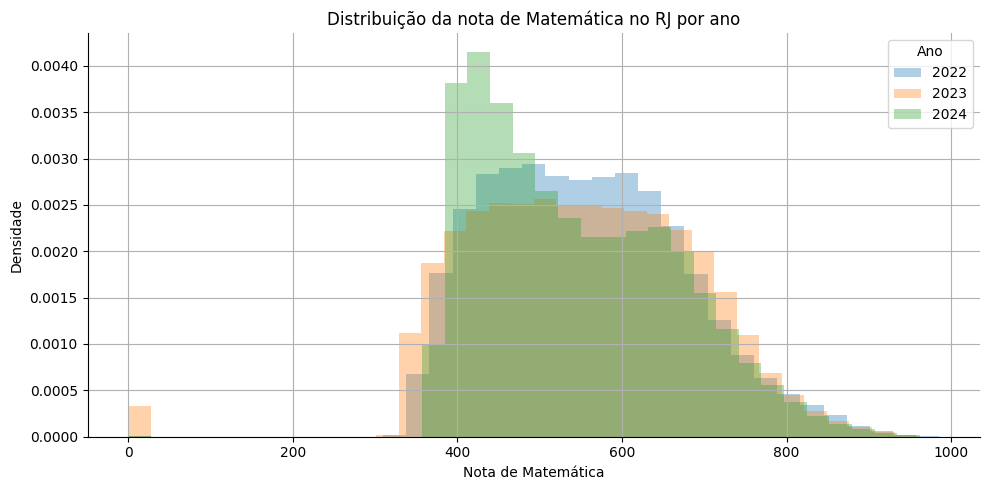

,NU_ANO,TP_ESCOLA,participantes,nota_mt_media,proporcao_alto
0,2022,1.0,99759,558.469810,0.236169
1,2022,2.0,46132,523.806445,0.138104
2,2022,3.0,23633,611.947683,0.406296
3,2023,1.0,114697,551.919960,0.265744
4,2023,2.0,45030,510.012481,0.139085
5,2023,3.0,25596,625.579825,0.488553


,NU_ANO,TP_COR_RACA,participantes,nota_mt_media,proporcao_alto
1,2022,1.0,84761,585.048623,0.317953
3,2022,3.0,52675,534.367349,0.164974
2,2022,2.0,26744,512.642503,0.107576
0,2022,0.0,3157,551.887583,0.220146
4,2022,4.0,1799,530.826237,0.162312
5,2022,5.0,388,500.786856,0.074742
7,2023,1.0,90629,586.379048,0.364651
9,2023,3.0,58788,527.197144,0.190787
8,2023,2.0,31386,500.272411,0.122411
6,2023,0.0,2386,556.953185,0.300922


,NU_ANO,Q006,participantes,nota_mt_media,proporcao_alto
1,2022,B,34489,500.239392,0.077039
2,2022,C,28422,523.638892,0.123637
3,2022,D,21851,539.242607,0.163517
4,2022,E,14820,556.204676,0.215047
7,2022,H,11482,598.155243,0.353161
6,2022,G,10780,583.505056,0.306122
5,2022,F,8721,571.811398,0.259833
0,2022,A,5557,487.491956,0.068742
8,2022,I,5246,608.579451,0.391727
16,2022,Q,4200,678.665071,0.631429


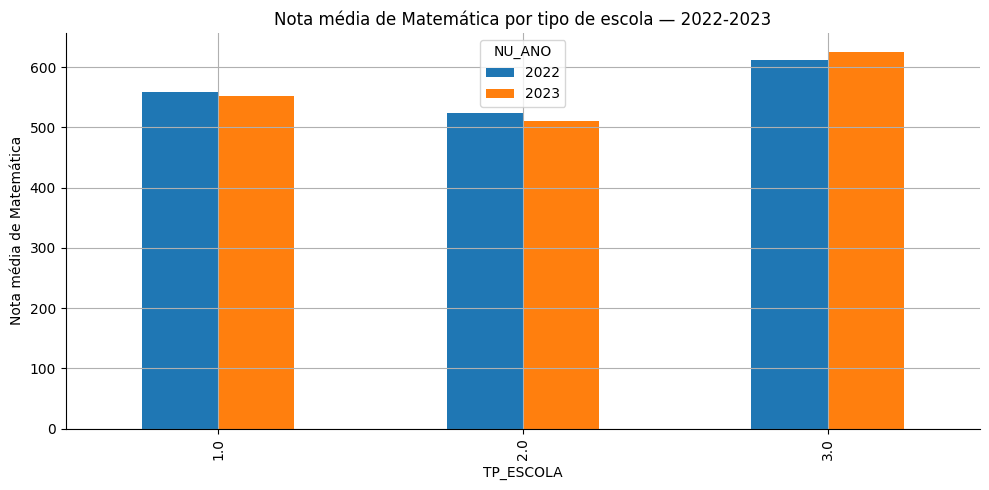

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
for year in sorted(EXPECTED_YEARS):
    scores = df_results.loc[df_results["NU_ANO"] == year, TARGET_SCORE_COLUMN]
    ax.hist(scores, bins=35, alpha=0.35, density=True, label=str(year))
ax.set_title("Distribuição da nota de Matemática no RJ por ano")
ax.set_xlabel("Nota de Matemática")
ax.set_ylabel("Densidade")
ax.legend(title="Ano")
fig.tight_layout()
fig.savefig(ARTIFACTS / "nota_mt_distribuicao_por_ano.png", dpi=160)
plt.show()

eda_a_base = df_results[df_results["NU_ANO"].isin(TRAIN_YEARS)].copy()
eda_a_base[TARGET_COLUMN] = (eda_a_base[TARGET_SCORE_COLUMN] >= eda_a_base[TARGET_SCORE_COLUMN].quantile(TARGET_QUANTILE)).astype(int)


school_table = grouped_score_table(eda_a_base, "TP_ESCOLA")
race_table = grouped_score_table(eda_a_base, "TP_COR_RACA")
income_table = grouped_score_table(eda_a_base, "Q006")

display(school_table.head(30))
display(race_table.head(30))
display(income_table.head(30))

school_table.to_csv(ARTIFACTS / "eda_model_a_by_school_type.csv", index=False)
race_table.to_csv(ARTIFACTS / "eda_model_a_by_race_color.csv", index=False)
income_table.to_csv(ARTIFACTS / "eda_model_a_by_income_proxy_q006.csv", index=False)

if not school_table.empty:
    pivot_school = school_table.pivot(index="TP_ESCOLA", columns="NU_ANO", values="nota_mt_media")
    ax = pivot_school.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Nota média de Matemática por tipo de escola — 2022-2023")
    ax.set_xlabel("TP_ESCOLA")
    ax.set_ylabel("Nota média de Matemática")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(ARTIFACTS / "model_a_nota_mt_media_por_tipo_escola.png", dpi=160)
    plt.show()


## Diferenças Entre os Dois Experimentos

**Modelo A:** utiliza atributos individuais, incluindo perfil, trajetória escolar e questionário socioeconômico. Seu objetivo é interpretativo e explicativo: responder à pergunta socioeducacional principal.

**Modelo B:** utiliza atributos comparáveis ao longo do tempo e agregados municipais. Seu objetivo é testar robustez temporal: avaliar se parte do padrão aprendido em 2022-2023 se mantém em 2024.

**Os dois modelos respondem perguntas diferentes e não devem ser interpretados como uma competição direta entre algoritmos.** Métricas de A e B são analisadas dentro de cada experimento, não como ranking único.


## Justificativa do target por P75

O percentil 75 foi escolhido porque representa um critério seletivo e interpretável de alto desempenho: o grupo no quarto superior da distribuição de Matemática. Essa definição é mais alinhada ao objetivo do MVP do que prever a média ou a mediana, pois foca em identificar desempenho elevado.

O limiar é calculado exclusivamente com dados de treino em cada experimento. Calcular o P75 usando teste ou 2024 permitiria que a distribuição dos dados de avaliação influenciasse a própria definição da variável-alvo, criando vazamento de dados e superestimando a validade da avaliação.

O princípio aplicado é: **o conjunto de avaliação nunca participa da definição do target, da otimização de hiperparâmetros ou do ajuste de transformações.**


# Experimento A — Modelo Socioeducacional Individual

Este é o experimento principal para a pergunta socioeducacional. Ele usa 2022-2023, onde perfil individual, questionário e resultados estão no mesmo registro. A avaliação é feita por divisão treino/teste estratificada dentro desses anos.


## Modelo A: preparação, split e target

Primeiro separam-se treino e teste. Depois o limiar P75 é calculado apenas no treino. Isso evita que a distribuição do teste influencie a construção do target.


In [25]:
model_a_base = df_results[df_results["NU_ANO"].isin(TRAIN_YEARS)].copy()
model_a_base = model_a_base.dropna(subset=[TARGET_SCORE_COLUMN]).copy()

model_a_train_df, model_a_test_df = train_test_split(
    model_a_base,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=model_a_base["NU_ANO"].astype(str),
)
model_a_threshold = model_a_train_df[TARGET_SCORE_COLUMN].quantile(TARGET_QUANTILE)
for frame in [model_a_train_df, model_a_test_df]:
    frame[TARGET_COLUMN] = (frame[TARGET_SCORE_COLUMN] >= model_a_threshold).astype(int)

model_a_feature_candidates = PROFILE_COLUMNS + SCHOOL_COLUMNS + PROVA_COLUMNS + QUESTIONARIO_COLUMNS_2022_2023
model_a_forbidden = set(PRESENCE_COLUMNS + SCORE_COLUMNS + REDACAO_COMP_COLUMNS + ["NU_INSCRICAO", "NU_ANO", TARGET_COLUMN])
model_a_features = [col for col in model_a_feature_candidates if col in model_a_train_df.columns and col not in model_a_forbidden]

constant_features_a = sorted(col for col in model_a_features if model_a_train_df[col].nunique(dropna=False) <= 1)
model_a_features = [col for col in model_a_features if col not in constant_features_a]
print(f"Features constantes removidas (recorte {RECORTE_UF}): {constant_features_a}")

X_a_train_full = model_a_train_df[model_a_features].copy()
y_a_train_full = model_a_train_df[TARGET_COLUMN].copy()
X_a_test = model_a_test_df[model_a_features].copy()
y_a_test = model_a_test_df[TARGET_COLUMN].copy()

model_a_split_summary = pd.DataFrame({
    "particao": ["treino_a", "teste_a"],
    "linhas": [len(X_a_train_full), len(X_a_test)],
    "proporcao_target_1": [y_a_train_full.mean(), y_a_test.mean()],
})
display(Markdown(f"Limiar P75 do Modelo A calculado apenas no treino: **{model_a_threshold:.2f}**."))
display(model_a_split_summary)

assert len(X_a_train_full) > 0 and len(X_a_test) > 0
assert set(y_a_train_full.unique()).issubset({0, 1})
assert TARGET_SCORE_COLUMN not in model_a_features
assert not any(col.startswith(LEAKAGE_PREFIXES) for col in model_a_features)
assert all(model_a_train_df[col].nunique(dropna=False) > 1 for col in model_a_features)


Limiar P75 do Modelo A calculado apenas no treino: **645.10**.

,particao,linhas,proporcao_target_1
0,treino_a,283877,0.250122
1,teste_a,70970,0.250486


## Modelo A: auditoria das features

Esta auditoria mostra quais variáveis individuais foram usadas e quais foram removidas por vazamento, contexto ou indisponibilidade. Ela torna a preparação dos dados verificável.


In [26]:
def build_feature_audit(all_columns: list[str], used_features: list[str], forbidden_columns: set[str], unavailable_columns: set[str] | None = None) -> pd.DataFrame:
    """Classifica colunas como usadas ou removidas e registra a justificativa metodológica."""
    unavailable_columns = unavailable_columns or set()
    rows = []
    for col in sorted(all_columns):
        if col in used_features:
            status, reason = "usada", "Feature permitida no desenho do experimento."
        elif col in forbidden_columns or col.startswith(LEAKAGE_PREFIXES):
            status, reason = "removida", "Vazamento, target, presença, nota, resposta, gabarito, prova ou identificador."
        elif col in unavailable_columns:
            status, reason = "removida", "Indisponível ou incompatível para este experimento."
        else:
            status, reason = "removida", "Fora da lista de features definida para o experimento."
        rows.append({"coluna": col, "status": status, "motivo": reason})
    return pd.DataFrame(rows)


In [27]:
feature_audit_model_a = build_feature_audit(list(model_a_train_df.columns), model_a_features, model_a_forbidden)
display(feature_audit_model_a)
feature_audit_model_a.to_csv(ARTIFACTS / "feature_audit_model_a.csv", index=False)
assert set(model_a_features) == set(feature_audit_model_a.loc[feature_audit_model_a["status"] == "usada", "coluna"])


,coluna,status,motivo
0,CO_MUNICIPIO_ESC,usada,Feature permitida no desenho do experimento.
1,CO_MUNICIPIO_PROVA,usada,Feature permitida no desenho do experimento.
2,CO_UF_ESC,usada,Feature permitida no desenho do experimento.
3,CO_UF_PROVA,usada,Feature permitida no desenho do experimento.
4,IN_TREINEIRO,usada,Feature permitida no desenho do experimento.
5,NO_MUNICIPIO_ESC,usada,Feature permitida no desenho do experimento.
6,NO_MUNICIPIO_PROVA,usada,Feature permitida no desenho do experimento.
7,NU_ANO,removida,"Vazamento, target, presença, nota, resposta, g..."
8,NU_INSCRICAO,removida,"Vazamento, target, presença, nota, resposta, g..."
9,NU_NOTA_CH,removida,"Vazamento, target, presença, nota, resposta, g..."


> **Nota sobre features constantes no Modelo A:** no recorte `SG_UF_PROVA == "RJ"`, as variáveis `SG_UF_PROVA` e `CO_UF_PROVA` tornam-se constantes (100% das observações com o mesmo valor) e não carregam nenhuma informação preditiva. Conforme a regra do projeto (`FEATURE_LEAKAGE_RULES.md`: *"não use SG_UF_PROVA como feature se ela se tornar constante"*) e a documentação de pré-processamento, a célula de preparação **detecta e remove programaticamente qualquer feature constante** antes do treino — a lista removida é impressa na saída da célula de split acima. Na auditoria de features, essas colunas aparecem com o status "removida" e motivo "fora da lista de features".

## Funções de modelagem e avaliação

As mesmas funções são usadas nos dois experimentos para manter comparação justa dentro de cada experimento: mesmo tipo de pipeline, mesmas métricas, mesma lógica de baseline e otimização.


In [28]:
def clean_feature_matrix(X: pd.DataFrame, categorical_features: list[str], numeric_features: list[str]) -> pd.DataFrame:
    """Padroniza tipos antes de enviar features ao Pipeline do scikit-learn."""
    X_clean = X.copy()
    for col in categorical_features:
        if col in X_clean.columns:
            X_clean[col] = X_clean[col].astype("object").where(X_clean[col].notna(), np.nan)
    for col in numeric_features:
        if col in X_clean.columns:
            X_clean[col] = pd.to_numeric(X_clean[col], errors="coerce")
    return X_clean


In [29]:
def make_preprocessor(categorical_features: list[str], numeric_features: list[str]) -> ColumnTransformer:
    """Cria um ColumnTransformer com imputação, one-hot encoding e escala quando aplicável."""
    transformers = []
    if categorical_features:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ))
    if numeric_features:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ))
    return ColumnTransformer(transformers)


In [30]:
def make_pipeline(model, categorical_features: list[str], numeric_features: list[str]) -> Pipeline:
    """Combina pré-processamento e estimador em um Pipeline reproduzível."""
    return Pipeline([
        ("preprocessor", make_preprocessor(categorical_features, numeric_features)),
        ("model", model),
    ])


In [31]:
def safe_roc_auc(y_true: pd.Series, y_score: np.ndarray) -> float:
    """Calcula ROC-AUC quando as duas classes estão presentes no conjunto avaliado."""
    return float(roc_auc_score(y_true, y_score)) if pd.Series(y_true).nunique() == 2 else np.nan


In [32]:
def get_score(estimator, X_eval: pd.DataFrame) -> np.ndarray:
    """Obtém escore contínuo ou probabilidade para métricas baseadas em ranking."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_eval)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_eval)
    return estimator.predict(X_eval)


In [33]:
def evaluate_classifier(name: str, estimator, X_eval: pd.DataFrame, y_eval: pd.Series, split_name: str, training_seconds: float | None = None) -> dict:
    """Calcula métricas de classificação e matriz de confusão para um estimador ajustado."""
    y_pred = estimator.predict(X_eval)
    y_score = get_score(estimator, X_eval)
    return {
        "modelo": name,
        "split": split_name,
        "accuracy": float(accuracy_score(y_eval, y_pred)),
        "precision": float(precision_score(y_eval, y_pred, zero_division=0)),
        "recall": float(recall_score(y_eval, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_eval, y_pred, zero_division=0)),
        "roc_auc": safe_roc_auc(y_eval, y_score),
        "confusion_matrix": confusion_matrix(y_eval, y_pred, labels=[0, 1]).tolist(),
        "training_seconds": None if training_seconds is None else float(training_seconds),
    }


In [34]:
def sample_training_data(X: pd.DataFrame, y: pd.Series, max_rows: int = MAX_TRAIN_ROWS_FOR_MODELING) -> tuple[pd.DataFrame, pd.Series]:
    """Reduz a base de treino de forma estratificada para manter tempo de execução viável."""
    if len(X) <= max_rows:
        return X.copy(), y.copy()
    temp = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True).rename(TARGET_COLUMN)], axis=1)
    sampled = temp.groupby(TARGET_COLUMN, group_keys=False).sample(frac=max_rows / len(temp), random_state=RANDOM_STATE)
    return sampled[X.columns].copy(), sampled[TARGET_COLUMN].copy()


In [35]:
def run_model_suite(
    experiment_label: str,
    X_train_full: pd.DataFrame,
    y_train_full: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    categorical_features: list[str],
    numeric_features: list[str],
    test_split_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame, dict, str]:
    """Treina baseline, modelos candidatos e Random Forest otimizada para um experimento."""
    X_train_full = clean_feature_matrix(X_train_full, categorical_features, numeric_features)
    X_test = clean_feature_matrix(X_test, categorical_features, numeric_features)
    X_train, y_train = sample_training_data(X_train_full, y_train_full)

    model_specs = {
        "DummyClassifier": DummyClassifier(strategy="most_frequent"),
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=120,
            max_depth=16,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    results = []
    trained_models = {}
    for name, model in model_specs.items():
        estimator = make_pipeline(model, categorical_features, numeric_features)
        start = time.perf_counter()
        estimator.fit(X_train, y_train)
        elapsed = time.perf_counter() - start
        trained_models[name] = estimator
        results.append(evaluate_classifier(name, estimator, X_train, y_train, "treino_modelagem", elapsed))
        results.append(evaluate_classifier(name, estimator, X_test, y_test, test_split_name, elapsed))

    rf_pipeline = make_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample"),
        categorical_features,
        numeric_features,
    )
    param_grid = {
        "model__n_estimators": [120],
        "model__max_depth": [12, 20],
        "model__min_samples_leaf": [3, 8],
    }
    grid_search = GridSearchCV(rf_pipeline, param_grid=param_grid, scoring="f1", cv=3, n_jobs=-1)
    start = time.perf_counter()
    grid_search.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    optimized_name = "RandomForestClassifier_Optimized"
    trained_models[optimized_name] = grid_search.best_estimator_
    results.append(evaluate_classifier(optimized_name, grid_search.best_estimator_, X_train, y_train, "treino_modelagem", elapsed))
    results.append(evaluate_classifier(optimized_name, grid_search.best_estimator_, X_test, y_test, test_split_name, elapsed))

    results_long = pd.DataFrame(results)
    test_results = (
        results_long[results_long["split"] == test_split_name]
        .drop(columns=["split"])
        .sort_values("f1_score", ascending=False)
        .reset_index(drop=True)
    )
    best_model_name = test_results.iloc[0]["modelo"]
    trained_models["grid_search_best_params"] = grid_search.best_params_
    trained_models["X_train_modeling_rows"] = len(X_train)

    print(f"{experiment_label}: linhas usadas no ajuste dos modelos: {len(X_train):,}")
    return test_results, results_long, trained_models, best_model_name


## Modelo A: treinamento, otimização e avaliação

O Modelo A testa H1 e H3 na avaliação convencional 2022-2023. Ele possui baseline explícito e modelos candidatos avaliados no mesmo conjunto de teste.


In [36]:
model_a_categorical_features = model_a_features
model_a_numeric_features: list[str] = []

model_a_results_df, model_a_results_long_df, model_a_trained, model_a_best_name = run_model_suite(
    "Modelo A",
    X_a_train_full,
    y_a_train_full,
    X_a_test,
    y_a_test,
    model_a_categorical_features,
    model_a_numeric_features,
    "teste_a_2022_2023",
)

display(model_a_results_df.drop(columns=["confusion_matrix"]))
model_a_baseline_f1 = float(model_a_results_df.loc[model_a_results_df["modelo"] == "DummyClassifier", "f1_score"].iloc[0])
model_a_best_f1 = float(model_a_results_df.iloc[0]["f1_score"])
model_a_supera_baseline = model_a_best_f1 > model_a_baseline_f1
print(f"Modelo A supera baseline? {model_a_supera_baseline} | F1 melhor: {model_a_best_f1:.4f} | F1 baseline: {model_a_baseline_f1:.4f}")
assert "DummyClassifier" in set(model_a_results_df["modelo"])
assert model_a_supera_baseline


Modelo A: linhas usadas no ajuste dos modelos: 60,000


,modelo,accuracy,precision,recall,f1_score,roc_auc,training_seconds
0,LogisticRegression,0.733239,0.479178,0.747595,0.584022,0.812762,1.153127
1,RandomForestClassifier,0.745118,0.493710,0.688755,0.575146,0.803350,3.722580
2,RandomForestClassifier_Optimized,0.755897,0.509850,0.659504,0.575101,0.804971,32.861701
3,DummyClassifier,0.749514,0.000000,0.000000,0.000000,0.500000,0.559406


Modelo A supera baseline? True | F1 melhor: 0.5840 | F1 baseline: 0.0000


## Modelo A: incerteza do F1 via validação cruzada

As métricas acima vêm de **um único split** treino/teste. Isso dá um número, mas não diz quanto ele variaria com outro sorteio dos dados — em particular, a diferença entre `LogisticRegression` e `RandomForestClassifier` no teste é pequena, e sem margem de erro não dá para saber se ela é real ou ruído de amostragem.

A célula abaixo roda **validação cruzada 5-fold apenas no conjunto de treino** (o teste permanece intocado — sem vazamento), com os mesmos hiperparâmetros dos modelos candidatos. O resultado é média ± desvio-padrão do F1, e uma resposta direta: a vantagem do modelo vencedor é maior que a variabilidade entre folds?

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_a_cv_base = clean_feature_matrix(X_a_train_full, model_a_categorical_features, model_a_numeric_features)
X_a_cv, y_a_cv = sample_training_data(X_a_cv_base, y_a_train_full)
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_model_specs = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

cv_rows = []
for cv_name, cv_model in cv_model_specs.items():
    cv_scores = cross_val_score(
        make_pipeline(cv_model, model_a_categorical_features, model_a_numeric_features),
        X_a_cv,
        y_a_cv,
        cv=cv_splitter,
        scoring="f1",
        n_jobs=-1,
    )
    cv_rows.append({
        "modelo": cv_name,
        "f1_cv_media": round(float(cv_scores.mean()), 4),
        "f1_cv_desvio": round(float(cv_scores.std()), 4),
        "f1_cv_min": round(float(cv_scores.min()), 4),
        "f1_cv_max": round(float(cv_scores.max()), 4),
    })

model_a_cv_df = pd.DataFrame(cv_rows)
display(model_a_cv_df)
model_a_cv_df.to_csv(ARTIFACTS / "model_a_cv_f1.csv", index=False)

f1_test_logreg = float(model_a_results_df.loc[model_a_results_df["modelo"] == "LogisticRegression", "f1_score"].iloc[0])
f1_test_rf = float(model_a_results_df.loc[model_a_results_df["modelo"] == "RandomForestClassifier", "f1_score"].iloc[0])
gap_teste = abs(f1_test_logreg - f1_test_rf)
desvio_cv_max = float(model_a_cv_df["f1_cv_desvio"].max())

if gap_teste <= 2 * desvio_cv_max:
    leitura_cv = (
        "a diferença entre os dois modelos no teste é **menor ou comparável à variabilidade entre folds** — "
        "ou seja, LogisticRegression e RandomForest são **estatisticamente indistinguíveis** neste desenho. "
        "A escolha da LogisticRegression se sustenta pela interpretabilidade (coeficientes), não por superioridade preditiva."
    )
else:
    leitura_cv = (
        "a diferença entre os modelos no teste **excede a variabilidade entre folds**, "
        "sugerindo vantagem consistente do modelo vencedor."
    )

display(Markdown(
    f"**Diferença LogReg−RF no teste:** {gap_teste:.4f} · **maior desvio-padrão do CV:** {desvio_cv_max:.4f}. "
    f"Leitura: {leitura_cv}"
))

## Modelo A: matriz de confusão, erros e overfitting

A matriz de confusão ajuda a interpretar falsos positivos e falsos negativos. A comparação entre F1 de treino e teste indica se há indício de overfitting.


In [37]:
def save_confusion_matrix(estimator, X_test: pd.DataFrame, y_test: pd.Series, title: str, path: Path) -> tuple[np.ndarray, pd.DataFrame]:
    """Salva a matriz de confusão e devolve uma tabela de erros por tipo."""
    y_pred = estimator.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Nao alto", "Alto"]).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()
    errors = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred})
    errors["tipo_erro"] = np.select(
        [
            (errors["y_true"] == 1) & (errors["y_pred"] == 0),
            (errors["y_true"] == 0) & (errors["y_pred"] == 1),
            (errors["y_true"] == errors["y_pred"]),
        ],
        ["falso_negativo", "falso_positivo", "acerto"],
        default="indefinido",
    )
    return cm, errors


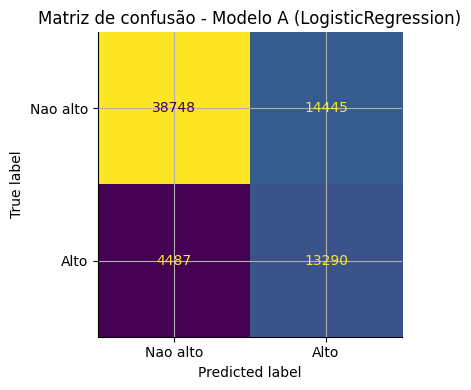

,tipo_erro,quantidade,percentual
0,acerto,52038,73.32
1,falso_positivo,14445,20.35
2,falso_negativo,4487,6.32


Modelo A - F1 treino: 0.5883; F1 teste: 0.5840; diferença: 0.0043


In [38]:
model_a_best_estimator = model_a_trained[model_a_best_name]
X_a_test_clean = clean_feature_matrix(X_a_test, model_a_categorical_features, model_a_numeric_features)
model_a_cm, model_a_errors = save_confusion_matrix(
    model_a_best_estimator,
    X_a_test_clean,
    y_a_test,
    f"Matriz de confusão - Modelo A ({model_a_best_name})",
    ARTIFACTS / "model_a_confusion_matrix.png",
)
model_a_error_summary = model_a_errors["tipo_erro"].value_counts().rename_axis("tipo_erro").reset_index(name="quantidade")
model_a_error_summary["percentual"] = (model_a_error_summary["quantidade"] / model_a_error_summary["quantidade"].sum() * 100).round(2)
display(model_a_error_summary)
model_a_error_summary.to_csv(ARTIFACTS / "model_a_error_summary.csv", index=False)

model_a_train_f1 = float(model_a_results_long_df[(model_a_results_long_df["modelo"] == model_a_best_name) & (model_a_results_long_df["split"] == "treino_modelagem")]["f1_score"].iloc[0])
model_a_gap = model_a_train_f1 - model_a_best_f1
print(f"Modelo A - F1 treino: {model_a_train_f1:.4f}; F1 teste: {model_a_best_f1:.4f}; diferença: {model_a_gap:.4f}")


## Modelo A: interpretabilidade e leitura de desigualdade

A pergunta socioeducacional só fica respondida se mostrarmos **quais** variáveis pesam e em que direção. Como o melhor modelo do Experimento A é a `LogisticRegression`, lemos seus coeficientes (log-odds) já com os nomes das features após a codificação. Coeficiente positivo eleva a chance de alto desempenho; negativo reduz.

A leitura é associativa, não causal, mas conecta o modelo à narrativa de desigualdade: renda (`Q006`), dependência administrativa da escola e perfil socioeconômico aparecem entre os fatores mais influentes.


In [ ]:
final_model_a = model_a_best_estimator.named_steps["model"]
feature_names_a = model_a_best_estimator.named_steps["preprocessor"].get_feature_names_out()
clean_names_a = [name.split("__", 1)[-1] for name in feature_names_a]

if hasattr(final_model_a, "coef_"):
    importance_values = final_model_a.coef_[0]
    importance_kind = "coeficiente (log-odds)"
else:
    importance_values = final_model_a.feature_importances_
    importance_kind = "importancia (Gini)"

model_a_importance = pd.DataFrame({"feature": clean_names_a, "valor": importance_values})
model_a_importance["abs_valor"] = model_a_importance["valor"].abs()
model_a_importance = model_a_importance.sort_values("abs_valor", ascending=False).reset_index(drop=True)
model_a_importance.to_csv(ARTIFACTS / "model_a_feature_importance.csv", index=False)

print(f"Importancia usada: {importance_kind}")
display(model_a_importance.drop(columns="abs_valor").head(15))

socio_prefixes = ("Q006", "TP_ESCOLA", "TP_ENSINO", "TP_DEPENDENCIA_ADM_ESC", "TP_COR_RACA")
socio_importance = (
    model_a_importance[model_a_importance["feature"].str.startswith(socio_prefixes)]
    .drop_duplicates("feature")
    .sort_values("valor")
)

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(socio_importance))))
ax.barh(socio_importance["feature"], socio_importance["valor"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Modelo A: coeficientes de variaveis socioeconomicas e escolares")
ax.set_xlabel("Coeficiente (log-odds): positivo eleva a chance de alto desempenho")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(ARTIFACTS / "model_a_socioeconomic_coefficients.png", dpi=160)
plt.show()

assert (ARTIFACTS / "model_a_feature_importance.csv").exists()


## Modelo A: erro por subgrupo (equidade descritiva)

A discussão ética fica mais forte com evidência, não só com prosa. A tabela abaixo mede, no conjunto de teste, a **taxa de falso negativo** (proporção de alunos de alto desempenho que o modelo deixa de identificar) e a **taxa de falso positivo** por tipo de escola e por cor/raça.

Diferenças grandes entre grupos indicam que a utilidade do modelo não é distribuída de forma uniforme — alerta direto para qualquer uso em política pública.


In [ ]:
def subgroup_error_table(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Calcula proporcao real de alto desempenho e taxas de erro por subgrupo."""
    rows = []
    for group_value, group_df in data.groupby(group_col, dropna=False):
        positives = group_df[group_df["y_true"] == 1]
        negatives = group_df[group_df["y_true"] == 0]
        rows.append({
            "grupo": f"{group_col}={group_value}",
            "n": len(group_df),
            "prop_alto_real": round(group_df["y_true"].mean(), 4),
            "taxa_falso_negativo": round((positives["y_pred"] == 0).mean(), 4) if len(positives) else np.nan,
            "taxa_falso_positivo": round((negatives["y_pred"] == 1).mean(), 4) if len(negatives) else np.nan,
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)


In [ ]:
y_pred_a_subgroup = model_a_best_estimator.predict(
    clean_feature_matrix(X_a_test, model_a_categorical_features, model_a_numeric_features)
)
subgroup_frame = pd.DataFrame({
    "TP_ESCOLA": model_a_test_df["TP_ESCOLA"].values,
    "TP_COR_RACA": model_a_test_df["TP_COR_RACA"].values,
    "y_true": y_a_test.values,
    "y_pred": y_pred_a_subgroup,
})

subgroup_error_school = subgroup_error_table(subgroup_frame, "TP_ESCOLA")
subgroup_error_race = subgroup_error_table(subgroup_frame, "TP_COR_RACA")
subgroup_error_model_a = pd.concat([subgroup_error_school, subgroup_error_race], ignore_index=True)
subgroup_error_model_a.to_csv(ARTIFACTS / "subgroup_error_model_a.csv", index=False)

display(Markdown("**TP_ESCOLA** (1 = nao respondeu, 2 = publica, 3 = privada)"))
display(subgroup_error_school)
display(Markdown("**TP_COR_RACA** (0 = nao declarado, 1 = Branca, 2 = Preta, 3 = Parda, 4 = Amarela, 5 = Indigena)"))
display(subgroup_error_race)

print(
    "Leitura: o modelo deixa de identificar uma fracao muito maior de alunos de alto desempenho "
    "da escola publica e de estudantes pretos, pardos e indigenas do que dos grupos de referencia."
)
assert (ARTIFACTS / "subgroup_error_model_a.csv").exists()


> **Limitações desta análise de equidade:**
>
> **1. Viés de seleção — 60,4% do test set não declarou escola.**
> `TP_ESCOLA = 1` ("não respondeu") representa **42.830 de 70.970 observações** no
> conjunto de teste. As taxas de FN e FP por escola pública/privada referem-se apenas
> aos **39,6% que declararam**. Perfis que não declaram escola (egressos, EJA, ensino
> em casa) podem ter distribuição de desempenho diferente — as taxas reportadas não
> generalizam para o total do teste.
>
> **2. Escola privada: FP = 66,9% — alerta adicional.**
> Além da baixa taxa de falso negativo (≈10,6%), o modelo classifica **~67% dos
> estudantes de escola privada *sem* alto desempenho real como "alto desempenho"**
> (TP_ESCOLA=3: FP = 0,668). Um sistema de seleção baseado neste modelo privilegiaria
> a escola privada por recall alto *e* FP alto simultaneamente. Qualquer uso prático
> exige revisão do limiar de decisão e consideração do custo assimétrico dos erros
> por grupo socioeconômico.

# Experimento B — Robustez Temporal

O Modelo B testa H2 e H3. Ele treina em 2022-2023 e avalia em 2024. Como 2024 não permite junção individual entre perfil e resultado, o perfil de 2024 entra apenas como agregado municipal.


## Agregados municipais de perfil

Os agregados municipais são calculados por `NU_ANO + CO_MUNICIPIO_PROVA`. Eles representam contexto municipal, não características individuais. Esse desenho permite usar informação de perfil em 2024 sem tentar reconstruir um relacionamento individual inexistente.


In [39]:
def make_municipal_profile_aggregates(profile_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Cria proporções municipais de variáveis de perfil sem junção individual em 2024."""
    keys = ["NU_ANO", "CO_MUNICIPIO_PROVA"]
    base = profile_df[keys].dropna().drop_duplicates().copy()
    group_size = profile_df.dropna(subset=keys).groupby(keys).size().rename("agg_profile_n")
    aggregates = group_size.reset_index()

    for col in columns:
        if col not in profile_df.columns:
            continue
        temp = profile_df[keys + [col]].dropna(subset=keys).copy()
        temp[col] = temp[col].astype("object").where(temp[col].notna(), "NA").astype(str)
        dummies = pd.get_dummies(temp[col], prefix=f"agg_{col}")
        temp_dummies = pd.concat([temp[keys], dummies], axis=1)
        sums = temp_dummies.groupby(keys).sum()
        props = sums.div(group_size, axis=0).reset_index()
        aggregates = aggregates.merge(props, on=keys, how="left")

    aggregate_cols = [col for col in aggregates.columns if col.startswith("agg_") and col != "agg_profile_n"]
    aggregates[aggregate_cols] = aggregates[aggregate_cols].fillna(0.0)
    return aggregates


In [40]:
municipal_aggregates = make_municipal_profile_aggregates(df_profiles, AGGREGATE_PROFILE_COLUMNS)
municipal_aggregates.to_csv(ARTIFACTS / "municipal_profile_aggregates_2022_2024.csv", index=False)
display(municipal_aggregates.head())
print("Agregados municipais:", municipal_aggregates.shape)

coverage_2024 = (
    df_results[df_results["NU_ANO"] == EXTERNAL_TEST_YEAR][["NU_ANO", "CO_MUNICIPIO_PROVA"]]
    .drop_duplicates()
    .merge(municipal_aggregates[["NU_ANO", "CO_MUNICIPIO_PROVA", "agg_profile_n"]], on=["NU_ANO", "CO_MUNICIPIO_PROVA"], how="left")
)
coverage_2024["tem_agregado"] = coverage_2024["agg_profile_n"].notna()
coverage_2024.to_csv(ARTIFACTS / "municipal_aggregate_coverage_2024.csv", index=False)
display(coverage_2024)

assert coverage_2024["tem_agregado"].all(), "Algum municipio de resultado 2024 ficou sem agregado municipal."
assert coverage_2024["CO_MUNICIPIO_PROVA"].nunique() == 52


,NU_ANO,CO_MUNICIPIO_PROVA,agg_profile_n,agg_Q006_A,agg_Q006_B,agg_Q006_C,agg_Q006_D,agg_Q006_E,agg_Q006_F,agg_Q006_G,agg_Q006_H,agg_Q006_I,agg_Q006_J,agg_Q006_K,agg_Q006_L,agg_Q006_M,agg_Q006_N,agg_Q006_O,agg_Q006_P,agg_Q006_Q,agg_TP_COR_RACA_0,agg_TP_COR_RACA_1,agg_TP_COR_RACA_2,agg_TP_COR_RACA_3,agg_TP_COR_RACA_4,agg_TP_COR_RACA_5,agg_TP_SEXO_F,agg_TP_SEXO_M,agg_TP_FAIXA_ETARIA_1,agg_TP_FAIXA_ETARIA_10,agg_TP_FAIXA_ETARIA_11,agg_TP_FAIXA_ETARIA_12,agg_TP_FAIXA_ETARIA_13,agg_TP_FAIXA_ETARIA_14,agg_TP_FAIXA_ETARIA_15,agg_TP_FAIXA_ETARIA_16,agg_TP_FAIXA_ETARIA_17,agg_TP_FAIXA_ETARIA_18,agg_TP_FAIXA_ETARIA_19,agg_TP_FAIXA_ETARIA_2,agg_TP_FAIXA_ETARIA_20,agg_TP_FAIXA_ETARIA_3,agg_TP_FAIXA_ETARIA_4,agg_TP_FAIXA_ETARIA_5,agg_TP_FAIXA_ETARIA_6,agg_TP_FAIXA_ETARIA_7,agg_TP_FAIXA_ETARIA_8,agg_TP_FAIXA_ETARIA_9,agg_IN_TREINEIRO_0,agg_IN_TREINEIRO_1,agg_TP_ST_CONCLUSAO_1,agg_TP_ST_CONCLUSAO_2,agg_TP_ST_CONCLUSAO_3,agg_TP_ST_CONCLUSAO_4,agg_TP_ENSINO_1.0,agg_TP_ENSINO_2.0,agg_TP_ENSINO_NA
0,2022,3300100,2157,0.041261,0.227631,0.179879,0.152527,0.085767,0.059805,0.060269,0.059805,0.026426,0.018081,0.015763,0.018081,0.016226,0.011590,0.009736,0.009272,0.007881,0.025035,0.502086,0.112656,0.343533,0.013908,0.002782,0.621697,0.378303,0.089013,0.018544,0.042652,0.026426,0.023180,0.014372,0.007881,0.005100,0.003245,0.002782,0.000464,0.192860,0.000464,0.244321,0.125174,0.070005,0.045433,0.032916,0.033380,0.021790,0.847473,0.152527,0.436718,0.408901,0.152527,0.001854,0.383403,0.001854,0.614743
1,2022,3300209,1876,0.046908,0.264392,0.191898,0.124733,0.083689,0.050640,0.059168,0.052239,0.029318,0.020789,0.014392,0.014925,0.012793,0.009595,0.008529,0.009595,0.006397,0.025053,0.439232,0.159382,0.363006,0.009595,0.003731,0.651386,0.348614,0.069829,0.016525,0.046375,0.025053,0.021322,0.013326,0.011194,0.009595,0.004797,0.002665,0.000533,0.175906,0.000533,0.251066,0.153518,0.078358,0.036247,0.034648,0.027186,0.021322,0.877399,0.122601,0.464286,0.410448,0.122601,0.002665,0.392324,0.003731,0.603945
2,2022,3300308,912,0.030702,0.232456,0.175439,0.127193,0.097588,0.061404,0.077851,0.075658,0.039474,0.028509,0.008772,0.008772,0.012061,0.008772,0.004386,0.007675,0.003289,0.015351,0.480263,0.203947,0.285088,0.014254,0.001096,0.633772,0.366228,0.100877,0.010965,0.037281,0.017544,0.009868,0.008772,0.004386,0.004386,0.001096,0.002193,0.000000,0.209430,0.000000,0.294956,0.141447,0.058114,0.039474,0.021930,0.018640,0.018640,0.823465,0.176535,0.351974,0.467105,0.176535,0.004386,0.450658,0.001096,0.548246
3,2022,3300407,2119,0.020293,0.195847,0.193016,0.141104,0.109014,0.067485,0.078811,0.066541,0.028787,0.019821,0.011326,0.017461,0.014630,0.009910,0.008495,0.006607,0.010854,0.014630,0.556395,0.148183,0.269467,0.008495,0.002832,0.607362,0.392638,0.102879,0.009910,0.036338,0.019349,0.013214,0.010382,0.005663,0.002360,0.001888,0.001416,0.000944,0.243983,0.000000,0.258613,0.126003,0.061822,0.037754,0.029259,0.020293,0.017933,0.826805,0.173195,0.378008,0.445965,0.173195,0.002832,0.433695,0.002360,0.563945
4,2022,3300456,3630,0.073829,0.349311,0.235537,0.131680,0.074656,0.036088,0.036639,0.031405,0.009642,0.004959,0.004408,0.004408,0.003581,0.001653,0.001653,0.000551,0.000000,0.028375,0.292287,0.252617,0.406612,0.018182,0.001928,0.646006,0.353994,0.039394,0.021212,0.061983,0.028650,0.023967,0.023691,0.012948,0.014325,0.006336,0.002755,0.000826,0.166942,0.000275,0.226446,0.128099,0.083471,0.054545,0.045455,0.031680,0.026997,0.942149,0.057851,0.550138,0.388705,0.057851,0.003306,0.364463,0.004683,0.630854


Agregados municipais: (156, 57)


,NU_ANO,CO_MUNICIPIO_PROVA,agg_profile_n,tem_agregado
0,2024,3304557,116924,True
1,2024,3302403,5506,True
2,2024,3306008,2021,True
3,2024,3303609,851,True
4,2024,3300100,2609,True
5,2024,3305109,7142,True
6,2024,3302205,2726,True
7,2024,3303401,4405,True
8,2024,3301009,8560,True
9,2024,3303708,810,True


## Limitações dos Agregados Municipais

Agregados municipais introduzem risco de **falácia ecológica**, que ocorre quando conclusões sobre indivíduos são inferidas indevidamente a partir de estatísticas agregadas de grupos.

Neste notebook, uma variável como a proporção municipal de determinada faixa de `Q006` não significa que um participante específico tenha aquela renda. Também não permite afirmar que um estudante pertence ao perfil médio do município. As interpretações válidas são contextuais: municípios com certos perfis agregados podem estar associados a diferenças de desempenho, mas isso não descreve indivíduos nem estabelece causalidade.


## EDA temporal: o perfil municipal mudou em 2024?

A distribuição das **notas** de 2024 já aparece na EDA inicial (histograma por ano). O que ainda não foi verificado é a **comparabilidade do perfil agregado** entre 2022-2023 e 2024 — pergunta central para H2 por dois motivos distintos:

1. **Mudança de população:** se o perfil real dos participantes de 2024 for muito diferente, a queda do Modelo B pode refletir público novo, não instabilidade dos padrões.
2. **Mudança de schema:** o questionário de 2024 foi **renumerado** (vai só até Q023). Se uma pergunta mudou de significado mantendo o mesmo código, as features agregadas treinadas em 2022-2023 recebem, em 2024, proporções de **outra pergunta** — corrupção silenciosa de feature no teste externo.

A tabela compara, para cada proporção municipal (`agg_*`), a média simples entre municípios em 2024 contra 2022-2023, ranqueada pelo desvio absoluto. A leitura automática abaixo separa os dois fenômenos: categorias que **zeram** em 2024 são assinatura de mudança de codificação (uma população não abandona 6 faixas de renda de um ano para o outro); o drift das demais features mede a mudança real de perfil.

In [ ]:
def municipal_profile_drift(aggregates: pd.DataFrame) -> pd.DataFrame:
    """Compara o perfil municipal agregado de 2024 com a média 2022-2023, feature a feature."""
    feature_cols = [col for col in aggregates.columns if col.startswith("agg_") and col != "agg_profile_n"]
    base_hist = aggregates[aggregates["NU_ANO"].isin(TRAIN_YEARS)]
    base_2024 = aggregates[aggregates["NU_ANO"] == EXTERNAL_TEST_YEAR]
    rows = []
    for col in feature_cols:
        if not base_2024[col].notna().any():
            continue
        media_hist = float(base_hist[col].mean())
        media_2024 = float(base_2024[col].mean())
        rows.append({
            "feature": col,
            "media_2022_2023": round(media_hist, 4),
            "media_2024": round(media_2024, 4),
            "drift_abs": round(abs(media_2024 - media_hist), 4),
        })
    return pd.DataFrame(rows).sort_values("drift_abs", ascending=False).reset_index(drop=True)

In [ ]:
profile_drift_df = municipal_profile_drift(municipal_aggregates)
display(profile_drift_df.head(15))
profile_drift_df.to_csv(ARTIFACTS / "municipal_profile_drift_2024.csv", index=False)

q006_levels_by_year = df_profiles.groupby("NU_ANO")["Q006"].nunique().rename("categorias_distintas_Q006")
display(q006_levels_by_year.to_frame())

schema_suspects = profile_drift_df[
    (profile_drift_df["media_2024"] == 0.0) & (profile_drift_df["media_2022_2023"] > 0.01)
]
suspect_prefixes = sorted({feat.rsplit("_", 1)[0] for feat in schema_suspects["feature"]})
if suspect_prefixes:
    is_suspect = profile_drift_df["feature"].apply(lambda f: f.startswith(tuple(suspect_prefixes)))
else:
    is_suspect = pd.Series(False, index=profile_drift_df.index)

drift_populacional = profile_drift_df[~is_suspect]
drift_max_pop = float(drift_populacional["drift_abs"].max())
feature_max_pop = str(drift_populacional.iloc[0]["feature"]) if len(drift_populacional) else "-"

if len(schema_suspects) > 0:
    leitura_schema = (
        f"**{len(schema_suspects)} categorias agregadas zeram em 2024** (prefixos: {', '.join(suspect_prefixes)}) — "
        f"assinatura de **mudança de codificação**, não de população. A contagem de categorias distintas de `Q006` "
        f"por ano confirma: { {int(year): int(n) for year, n in q006_levels_by_year.items()} }. Em 2024, `Q006` é **outra pergunta** (binária), e as "
        f"features `agg_Q006_*` do Modelo B estão **semanticamente corrompidas no teste externo** — o modelo "
        f"aprendeu proporções de faixas de renda e recebeu proporções de uma pergunta diferente. "
        f"O impacto disso é quantificado no experimento de sensibilidade da seção de decomposição de H2."
    )
else:
    leitura_schema = "Nenhuma categoria agregada zera em 2024 — sem indício de mudança de codificação."

if drift_max_pop < 0.05:
    leitura_pop = (
        f"Excluído o bloco suspeito de schema, o drift máximo das demais features é **{drift_max_pop:.4f}** "
        f"(`{feature_max_pop}`) — o perfil **populacional** de 2024 é essencialmente estável. "
        f"A queda do Modelo B não é explicada por mudança de público."
    )
else:
    leitura_pop = (
        f"Mesmo fora do bloco suspeito, há drift de até **{drift_max_pop:.4f}** (`{feature_max_pop}`) — "
        f"parte da queda do Modelo B pode refletir mudança real de perfil."
    )

display(Markdown(f"{leitura_schema}\n\n{leitura_pop}"))

## Modelo B: preparação, target e features

O limiar P75 do Modelo B é calculado apenas com o treino temporal 2022-2023. O teste externo de 2024 não participa da definição do target nem da otimização de hiperparâmetros.


In [41]:
model_b_base = df_results.merge(municipal_aggregates, on=["NU_ANO", "CO_MUNICIPIO_PROVA"], how="left")
model_b_train_df = model_b_base[model_b_base["NU_ANO"].isin(TRAIN_YEARS)].copy()
model_b_test_df = model_b_base[model_b_base["NU_ANO"] == EXTERNAL_TEST_YEAR].copy()
model_b_threshold = model_b_train_df[TARGET_SCORE_COLUMN].quantile(TARGET_QUANTILE)
for frame in [model_b_train_df, model_b_test_df]:
    frame[TARGET_COLUMN] = (frame[TARGET_SCORE_COLUMN] >= model_b_threshold).astype(int)

model_b_direct_features = [col for col in SCHOOL_COLUMNS + ["CO_MUNICIPIO_PROVA", "NO_MUNICIPIO_PROVA"] if col in model_b_base.columns]
model_b_aggregate_features = [col for col in municipal_aggregates.columns if col.startswith("agg_")]
model_b_features = model_b_direct_features + model_b_aggregate_features
model_b_forbidden = set(PRESENCE_COLUMNS + SCORE_COLUMNS + REDACAO_COMP_COLUMNS + ["NU_ANO", TARGET_COLUMN, "SG_UF_PROVA", "CO_UF_PROVA"])
model_b_features = [col for col in model_b_features if col not in model_b_forbidden and not col.startswith(LEAKAGE_PREFIXES)]

model_b_numeric_features = [col for col in model_b_features if col.startswith("agg_")]
model_b_categorical_features = [col for col in model_b_features if col not in model_b_numeric_features]

X_b_train_full = model_b_train_df[model_b_features].copy()
y_b_train_full = model_b_train_df[TARGET_COLUMN].copy()
X_b_test = model_b_test_df[model_b_features].copy()
y_b_test = model_b_test_df[TARGET_COLUMN].copy()

model_b_split_summary = pd.DataFrame({
    "particao": ["treino_b_2022_2023", "teste_b_2024"],
    "linhas": [len(X_b_train_full), len(X_b_test)],
    "proporcao_target_1": [y_b_train_full.mean(), y_b_test.mean()],
})
display(Markdown(f"Limiar P75 do Modelo B calculado apenas no treino temporal 2022-2023: **{model_b_threshold:.2f}**."))
display(model_b_split_summary)

assert len(X_b_train_full) > 0 and len(X_b_test) > 0
assert TARGET_SCORE_COLUMN not in model_b_features
assert not any(col.startswith(LEAKAGE_PREFIXES) for col in model_b_features)
assert not X_b_test[model_b_numeric_features].isna().all(axis=None)


Limiar P75 do Modelo B calculado apenas no treino temporal 2022-2023: **645.10**.

,particao,linhas,proporcao_target_1
0,treino_b_2022_2023,354847,0.250195
1,teste_b_2024,202316,0.223823


## Rastreabilidade do fluxo de dados

A tabela abaixo registra as dimensões em etapas críticas. Ela permite reconstruir como os microdados brutos chegam às bases usadas nos dois experimentos.


In [42]:
result_metadata_df = pd.DataFrame(result_metadata)
profile_metadata_df = pd.DataFrame(profile_metadata)

data_flow_rows = []
for row in result_metadata_df.to_dict("records"):
    data_flow_rows.append({
        "etapa": "resultados_brutos_lidos",
        "ano": row["year"],
        "linhas": row["rows_seen"],
        "detalhe": row["csv_member"],
    })
    data_flow_rows.append({
        "etapa": "resultados_rj_presenca_mt_nota_valida",
        "ano": row["year"],
        "linhas": row["rows_kept_score_valid_rj"],
        "detalhe": "SG_UF_PROVA == RJ; TP_PRESENCA_MT == 1; NU_NOTA_MT válida",
    })
for row in profile_metadata_df.to_dict("records"):
    data_flow_rows.append({
        "etapa": "perfis_rj_lidos",
        "ano": row["year"],
        "linhas": row["rows_kept_profile_rj"],
        "detalhe": "SG_UF_PROVA == RJ na base de perfil/participantes",
    })

data_flow_rows.extend([
    {"etapa": "modelo_a_treino_2022_2023", "ano": "2022-2023", "linhas": len(X_a_train_full), "detalhe": "Split estratificado; P75 calculado apenas aqui."},
    {"etapa": "modelo_a_teste_2022_2023", "ano": "2022-2023", "linhas": len(X_a_test), "detalhe": "Teste interno não usado para definir P75."},
    {"etapa": "agregados_municipais", "ano": "2022-2024", "linhas": len(municipal_aggregates), "detalhe": "Proporções por NU_ANO + CO_MUNICIPIO_PROVA."},
    {"etapa": "cobertura_agregados_2024", "ano": 2024, "linhas": int(coverage_2024["tem_agregado"].sum()), "detalhe": "Municípios de resultado 2024 com agregado municipal."},
    {"etapa": "modelo_b_treino_2022_2023", "ano": "2022-2023", "linhas": len(X_b_train_full), "detalhe": "Treino temporal; P75 calculado apenas aqui."},
    {"etapa": "modelo_b_teste_externo_2024", "ano": 2024, "linhas": len(X_b_test), "detalhe": "Teste externo sem uso em target ou tuning."},
])

data_flow_trace = pd.DataFrame(data_flow_rows)
display(data_flow_trace)
data_flow_trace.to_csv(ARTIFACTS / "data_flow_trace.csv", index=False)
assert {"modelo_a_treino_2022_2023", "modelo_b_teste_externo_2024"}.issubset(set(data_flow_trace["etapa"]))


,etapa,ano,linhas,detalhe
0,resultados_brutos_lidos,2022,3476105,DADOS/MICRODADOS_ENEM_2022.csv
1,resultados_rj_presenca_mt_nota_valida,2022,169524,SG_UF_PROVA == RJ; TP_PRESENCA_MT == 1; NU_NOT...
2,resultados_brutos_lidos,2023,3933955,DADOS/MICRODADOS_ENEM_2023.csv
3,resultados_rj_presenca_mt_nota_valida,2023,185323,SG_UF_PROVA == RJ; TP_PRESENCA_MT == 1; NU_NOT...
4,resultados_brutos_lidos,2024,4332944,DADOS/RESULTADOS_2024.csv
5,resultados_rj_presenca_mt_nota_valida,2024,202316,SG_UF_PROVA == RJ; TP_PRESENCA_MT == 1; NU_NOT...
6,perfis_rj_lidos,2022,250890,SG_UF_PROVA == RJ na base de perfil/participantes
7,perfis_rj_lidos,2023,282296,SG_UF_PROVA == RJ na base de perfil/participantes
8,perfis_rj_lidos,2024,289397,SG_UF_PROVA == RJ na base de perfil/participantes
9,modelo_a_treino_2022_2023,2022-2023,283877,Split estratificado; P75 calculado apenas aqui.


## Modelo B: auditoria das features

A auditoria documenta a separação entre features diretas e agregados municipais. O uso dos agregados é contextual e nunca individual.


In [43]:
feature_audit_model_b = build_feature_audit(list(model_b_base.columns), model_b_features, model_b_forbidden)
feature_audit_model_b["tipo_feature"] = np.select(
    [feature_audit_model_b["coluna"].isin(model_b_numeric_features), feature_audit_model_b["coluna"].isin(model_b_categorical_features)],
    ["agregado_municipal", "direta_comparavel"],
    default="nao_usada",
)
display(feature_audit_model_b)
feature_audit_model_b.to_csv(ARTIFACTS / "feature_audit_model_b.csv", index=False)
assert set(model_b_features) == set(feature_audit_model_b.loc[feature_audit_model_b["status"] == "usada", "coluna"])


,coluna,status,motivo,tipo_feature
0,CO_MUNICIPIO_ESC,usada,Feature permitida no desenho do experimento.,direta_comparavel
1,CO_MUNICIPIO_PROVA,usada,Feature permitida no desenho do experimento.,direta_comparavel
2,CO_UF_ESC,usada,Feature permitida no desenho do experimento.,direta_comparavel
3,CO_UF_PROVA,removida,"Vazamento, target, presença, nota, resposta, g...",nao_usada
4,IN_TREINEIRO,removida,Fora da lista de features definida para o expe...,nao_usada
...,...,...,...,...
112,agg_TP_ST_CONCLUSAO_1,usada,Feature permitida no desenho do experimento.,agregado_municipal
113,agg_TP_ST_CONCLUSAO_2,usada,Feature permitida no desenho do experimento.,agregado_municipal
114,agg_TP_ST_CONCLUSAO_3,usada,Feature permitida no desenho do experimento.,agregado_municipal
115,agg_TP_ST_CONCLUSAO_4,usada,Feature permitida no desenho do experimento.,agregado_municipal


## Auditoria das variáveis excluídas

Esta auditoria consolida o que ficou fora dos pipelines. O objetivo é tornar explícitas as exclusões por vazamento, incompatibilidade de schema, identificadores, colunas constantes ou ausência de relação direta com o desenho do experimento.


In [44]:
excluded_variables_audit = pd.concat([
    feature_audit_model_a.assign(experimento="Modelo A"),
    feature_audit_model_b.assign(experimento="Modelo B"),
], ignore_index=True)
excluded_variables_audit = excluded_variables_audit[excluded_variables_audit["status"] == "removida"].copy()
excluded_variables_audit.to_csv(ARTIFACTS / "excluded_variables_audit.csv", index=False)
display(excluded_variables_audit.head(40))
assert not excluded_variables_audit.empty
leakage_removed_a = set(feature_audit_model_a.loc[feature_audit_model_a["motivo"].str.contains("Vazamento", na=False), "coluna"])
leakage_removed_b = set(feature_audit_model_b.loc[feature_audit_model_b["motivo"].str.contains("Vazamento", na=False), "coluna"])
assert leakage_removed_a.isdisjoint(model_a_features)
assert leakage_removed_b.isdisjoint(model_b_features)


,coluna,status,motivo,experimento,tipo_feature
7,NU_ANO,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
8,NU_INSCRICAO,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
9,NU_NOTA_CH,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
10,NU_NOTA_CN,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
11,NU_NOTA_COMP1,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
12,NU_NOTA_COMP2,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
13,NU_NOTA_COMP3,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
14,NU_NOTA_COMP4,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
15,NU_NOTA_COMP5,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN
16,NU_NOTA_LC,removida,"Vazamento, target, presença, nota, resposta, g...",Modelo A,NaN


## Modelo B: treinamento, baseline temporal e avaliação externa

O baseline temporal é obrigatório: `DummyClassifier(strategy="most_frequent")`, treinado em 2022-2023 e avaliado no mesmo conjunto externo de 2024. A pergunta respondida explicitamente é: **o modelo temporal supera um baseline temporal?**


In [45]:
model_b_results_df, model_b_results_long_df, model_b_trained, model_b_best_name = run_model_suite(
    "Modelo B",
    X_b_train_full,
    y_b_train_full,
    X_b_test,
    y_b_test,
    model_b_categorical_features,
    model_b_numeric_features,
    "teste_externo_2024",
)

display(model_b_results_df.drop(columns=["confusion_matrix"]))
model_b_baseline_f1 = float(model_b_results_df.loc[model_b_results_df["modelo"] == "DummyClassifier", "f1_score"].iloc[0])
model_b_best_f1 = float(model_b_results_df.iloc[0]["f1_score"])
model_b_supera_baseline = model_b_best_f1 > model_b_baseline_f1
print(f"O modelo temporal supera um baseline temporal? {model_b_supera_baseline}")
print(f"F1 melhor modelo temporal: {model_b_best_f1:.4f}; F1 baseline temporal: {model_b_baseline_f1:.4f}")
assert "DummyClassifier" in set(model_b_results_df["modelo"])
assert model_b_supera_baseline


Modelo B: linhas usadas no ajuste dos modelos: 60,000


,modelo,accuracy,precision,recall,f1_score,roc_auc,training_seconds
0,LogisticRegression,0.401140,0.259810,0.906234,0.403842,0.657147,2.767989
1,RandomForestClassifier_Optimized,0.772870,0.483812,0.220767,0.303187,0.662721,43.134391
2,RandomForestClassifier,0.772277,0.479115,0.199854,0.282054,0.674062,5.062412
3,DummyClassifier,0.776177,0.000000,0.000000,0.000000,0.500000,0.448378


O modelo temporal supera um baseline temporal? True
F1 melhor modelo temporal: 0.4038; F1 baseline temporal: 0.0000


## Modelo B: matriz de confusão, erros e overfitting temporal

A avaliação externa em 2024 mede robustez temporal. A diferença entre F1 de treino e F1 externo sinaliza o quanto os padrões aprendidos permanecem úteis em outro ano.


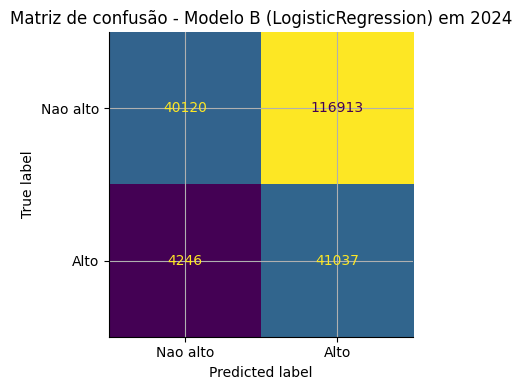

,tipo_erro,quantidade,percentual
0,falso_positivo,116913,57.79
1,acerto,81157,40.11
2,falso_negativo,4246,2.10


Modelo B - F1 treino: 0.4395; F1 externo 2024: 0.4038; diferença: 0.0356


In [46]:
model_b_best_estimator = model_b_trained[model_b_best_name]
X_b_test_clean = clean_feature_matrix(X_b_test, model_b_categorical_features, model_b_numeric_features)
model_b_cm, model_b_errors = save_confusion_matrix(
    model_b_best_estimator,
    X_b_test_clean,
    y_b_test,
    f"Matriz de confusão - Modelo B ({model_b_best_name}) em 2024",
    ARTIFACTS / "model_b_confusion_matrix_2024.png",
)
model_b_error_summary = model_b_errors["tipo_erro"].value_counts().rename_axis("tipo_erro").reset_index(name="quantidade")
model_b_error_summary["percentual"] = (model_b_error_summary["quantidade"] / model_b_error_summary["quantidade"].sum() * 100).round(2)
display(model_b_error_summary)
model_b_error_summary.to_csv(ARTIFACTS / "model_b_error_summary_2024.csv", index=False)

model_b_train_f1 = float(model_b_results_long_df[(model_b_results_long_df["modelo"] == model_b_best_name) & (model_b_results_long_df["split"] == "treino_modelagem")]["f1_score"].iloc[0])
model_b_gap = model_b_train_f1 - model_b_best_f1
print(f"Modelo B - F1 treino: {model_b_train_f1:.4f}; F1 externo 2024: {model_b_best_f1:.4f}; diferença: {model_b_gap:.4f}")


## Modelo B: leitura operacional honesta

Superar o `DummyClassifier(strategy="most_frequent")` é um teste fraco: esse baseline prevê sempre "não alto" e tem F1 = 0 por construção. Antes de comemorar, é preciso olhar o que o Modelo B faz na prática em 2024.


In [ ]:
tn_b, fp_b = int(model_b_cm[0][0]), int(model_b_cm[0][1])
fn_b, tp_b = int(model_b_cm[1][0]), int(model_b_cm[1][1])
total_b = tn_b + fp_b + fn_b + tp_b
pred_pos_b = fp_b + tp_b
precision_b = tp_b / (tp_b + fp_b) if (tp_b + fp_b) else float("nan")
recall_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) else float("nan")

print(f"Modelo B marca como 'alto desempenho': {pred_pos_b:,} de {total_b:,} ({pred_pos_b / total_b:.1%}).")
print(f"Precision = {precision_b:.3f} | Recall = {recall_b:.3f}")
print(f"Falsos positivos: {fp_b:,} ({fp_b / total_b:.1%} de todos os participantes de 2024).")
print(
    "Conclusao operacional: com AUC ~0.66 ha sinal fraco de ranqueamento, mas no limiar padrao o "
    "Modelo B rotula a maioria dos estudantes como 'alto' e tem baixa precisao. Serve como score "
    "contextual agregado, nao como classificador individual."
)


## Avaliação integrada sem comparação injusta

O Modelo A e o Modelo B são analisados em conjunto para responder à tese do estudo, mas não são ranqueados como se fossem o mesmo experimento. O Modelo A tem maior riqueza individual; o Modelo B tem maior rigor temporal.


,experimento,avaliacao,modelo,accuracy,precision,recall,f1_score,roc_auc,training_seconds
0,Modelo A - socioeducacional individual,teste interno 2022-2023,LogisticRegression,0.733239,0.479178,0.747595,0.584022,0.812762,1.153127
1,Modelo A - socioeducacional individual,teste interno 2022-2023,RandomForestClassifier,0.745118,0.493710,0.688755,0.575146,0.803350,3.722580
2,Modelo A - socioeducacional individual,teste interno 2022-2023,RandomForestClassifier_Optimized,0.755897,0.509850,0.659504,0.575101,0.804971,32.861701
3,Modelo A - socioeducacional individual,teste interno 2022-2023,DummyClassifier,0.749514,0.000000,0.000000,0.000000,0.500000,0.559406
4,Modelo B - robustez temporal,teste externo 2024,LogisticRegression,0.401140,0.259810,0.906234,0.403842,0.657147,2.767989
5,Modelo B - robustez temporal,teste externo 2024,RandomForestClassifier_Optimized,0.772870,0.483812,0.220767,0.303187,0.662721,43.134391
6,Modelo B - robustez temporal,teste externo 2024,RandomForestClassifier,0.772277,0.479115,0.199854,0.282054,0.674062,5.062412
7,Modelo B - robustez temporal,teste externo 2024,DummyClassifier,0.776177,0.000000,0.000000,0.000000,0.500000,0.448378


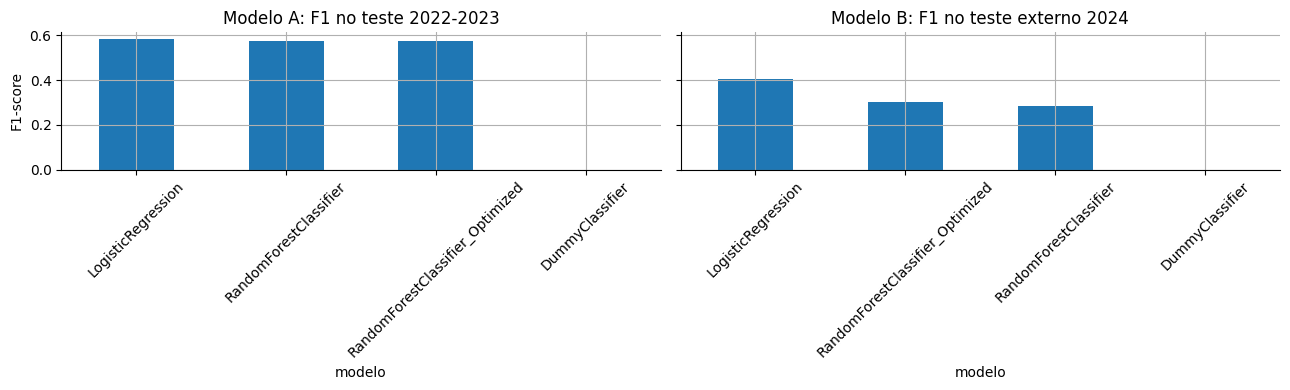

Os dois modelos respondem perguntas diferentes e não devem ser interpretados como uma competição direta entre algoritmos.


In [47]:
model_a_summary = model_a_results_df.assign(experimento="Modelo A - socioeducacional individual", avaliacao="teste interno 2022-2023")
model_b_summary = model_b_results_df.assign(experimento="Modelo B - robustez temporal", avaliacao="teste externo 2024")
combined_results = pd.concat([model_a_summary, model_b_summary], ignore_index=True)
metric_cols = ["experimento", "avaliacao", "modelo", "accuracy", "precision", "recall", "f1_score", "roc_auc", "training_seconds"]
display(combined_results[metric_cols])

combined_results[metric_cols].to_csv(ARTIFACTS / "model_results.csv", index=False)
model_a_results_df[metric_cols[2:]].to_csv(ARTIFACTS / "model_a_individual_results.csv", index=False)
model_b_results_df[metric_cols[2:]].to_csv(ARTIFACTS / "model_b_temporal_results.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
model_a_results_df.set_index("modelo")["f1_score"].plot(kind="bar", ax=axes[0], title="Modelo A: F1 no teste 2022-2023")
model_b_results_df.set_index("modelo")["f1_score"].plot(kind="bar", ax=axes[1], title="Modelo B: F1 no teste externo 2024")
for ax in axes:
    ax.set_ylabel("F1-score")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(ARTIFACTS / "f1_by_experiment_not_direct_comparison.png", dpi=160)
plt.show()

print("Os dois modelos respondem perguntas diferentes e não devem ser interpretados como uma competição direta entre algoritmos.")


## Ganho real sobre um baseline honesto

O baseline `most_frequent` usado acima tem F1 = 0 por construção, o que torna a frase "supera o baseline" pouco informativa. Aqui usamos um baseline mais justo — `DummyClassifier(strategy="stratified")`, que respeita a prevalência da classe positiva — e reportamos o ganho absoluto e percentual de cada experimento.


In [ ]:
def fair_baseline_f1(y_train: pd.Series, y_test: pd.Series) -> float:
    """F1 de um baseline estratificado que respeita a prevalencia da classe positiva."""
    baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
    baseline.fit(np.zeros((len(y_train), 1)), y_train)
    return float(f1_score(y_test, baseline.predict(np.zeros((len(y_test), 1)))))


In [ ]:
f1_fair_baseline_a = fair_baseline_f1(y_a_train_full, y_a_test)
f1_fair_baseline_b = fair_baseline_f1(y_b_train_full, y_b_test)

honest_gain = pd.DataFrame([
    {
        "experimento": "Modelo A (teste interno 2022-2023)",
        "melhor_modelo": model_a_best_name,
        "f1_melhor": round(model_a_best_f1, 4),
        "f1_baseline_most_frequent": round(model_a_baseline_f1, 4),
        "f1_baseline_estratificado": round(f1_fair_baseline_a, 4),
        "ganho_abs_vs_estratificado": round(model_a_best_f1 - f1_fair_baseline_a, 4),
        "ganho_rel_vs_estratificado_pct": round((model_a_best_f1 - f1_fair_baseline_a) / f1_fair_baseline_a * 100, 1),
    },
    {
        "experimento": "Modelo B (teste externo 2024)",
        "melhor_modelo": model_b_best_name,
        "f1_melhor": round(model_b_best_f1, 4),
        "f1_baseline_most_frequent": round(model_b_baseline_f1, 4),
        "f1_baseline_estratificado": round(f1_fair_baseline_b, 4),
        "ganho_abs_vs_estratificado": round(model_b_best_f1 - f1_fair_baseline_b, 4),
        "ganho_rel_vs_estratificado_pct": round((model_b_best_f1 - f1_fair_baseline_b) / f1_fair_baseline_b * 100, 1),
    },
])
display(honest_gain)
honest_gain.to_csv(ARTIFACTS / "honest_baseline_gain.csv", index=False)
print(
    "Leitura: contra um baseline honesto, o Modelo A entrega ganho grande e o Modelo B um ganho "
    "moderado. Nenhum dos dois e trivial, mas o Modelo B e bem mais modesto do que a comparacao "
    "com o baseline degenerado sugeria."
)
assert (ARTIFACTS / "honest_baseline_gain.csv").exists()


## A otimização de hiperparâmetros trouxe benefício real?

O `GridSearchCV` ajustou a Random Forest, mas o critério de avaliação pede uma resposta explícita: a versão otimizada superou o modelo simples?


In [ ]:
def optimization_benefit(experiment: str, results_df: pd.DataFrame) -> dict:
    """Compara F1 da Random Forest simples, otimizada e do melhor modelo simples."""
    f1_by_model = results_df.set_index("modelo")["f1_score"]
    f1_rf = float(f1_by_model.get("RandomForestClassifier", float("nan")))
    f1_rf_opt = float(f1_by_model.get("RandomForestClassifier_Optimized", float("nan")))
    f1_logreg = float(f1_by_model.get("LogisticRegression", float("nan")))
    winner = results_df.sort_values("f1_score", ascending=False).iloc[0]["modelo"]
    return {
        "experimento": experiment,
        "f1_logreg": round(f1_logreg, 4),
        "f1_rf_simples": round(f1_rf, 4),
        "f1_rf_otimizada": round(f1_rf_opt, 4),
        "otim_superou_rf_simples": bool(f1_rf_opt > f1_rf),
        "otim_superou_modelo_vencedor": bool(f1_rf_opt >= f1_by_model.max()),
        "modelo_vencedor": winner,
    }


In [ ]:
optimization_summary = pd.DataFrame([
    optimization_benefit("Modelo A", model_a_results_df),
    optimization_benefit("Modelo B", model_b_results_df),
])
display(optimization_summary)
optimization_summary.to_csv(ARTIFACTS / "optimization_benefit_summary.csv", index=False)
print(
    "Resposta: a Random Forest otimizada nao venceu o modelo simples (LogisticRegression) em nenhum "
    "experimento. A otimizacao trouxe, no maximo, ganho marginal dentro da propria familia Random "
    "Forest. Para este MVP, o modelo linear simples foi a melhor escolha."
)
assert (ARTIFACTS / "optimization_benefit_summary.csv").exists()


## Por que H2 não é plenamente testável neste desenho

O Modelo A aprende com atributos **individuais**; o Modelo B, com **agregados municipais**. Logo, a queda de F1 (de ~0,58 para ~0,40) mistura dois efeitos que este desenho **não separa**:

1. **Perda de granularidade** — trocar features individuais por contexto municipal, por si só, derruba o desempenho mesmo sem nenhuma mudança temporal;
2. **Drift temporal real** — eventuais mudanças na relação entre variáveis e desempenho entre 2022-2023 e 2024.

A impossibilidade de junção individual em 2024 é uma limitação real dos microdados, não uma escolha. Por isso H2 é respondida apenas de forma parcial e como **proxy fraco**: há sinal contextual remanescente em 2024, mas não se pode atribuir a queda à estabilidade (ou instabilidade) dos padrões individuais. Próximo passo honesto: treinar um modelo restrito às features municipais também no teste interno de 2022-2023, isolando quanto da queda vem da granularidade e quanto vem do ano.


## Decompondo a queda: granularidade ou tempo?

A seção anterior mostrou que a queda de F1 entre o Modelo A (0,58 interno) e o Modelo B (0,40 externo) mistura dois efeitos que o desenho original não separa: a **perda de granularidade** (trocar atributos individuais por agregados municipais) e o **drift temporal** (2024 ser um ano diferente).

O experimento abaixo separa os dois fatores: treina uma `LogisticRegression` com as **mesmas features do Modelo B** (diretas comparáveis + agregados municipais), mas em um **split interno 80/20 de 2022-2023** — ou seja, sem mudar de ano. A disciplina anti-vazamento é idêntica à do Modelo A: P75 recalculado apenas no treino interno, teste intocado.

A leitura é direta:

- **F1 individual interno → F1 municipal interno** = custo da granularidade (mesmo período);
- **F1 municipal interno → F1 municipal externo 2024** = drift temporal puro (mesmas features).

*Ressalva:* a comparação não é perfeitamente simétrica — as features diretas do Modelo B (atributos de escola) diferem das do Modelo A (perfil + questionário individual) — mas isola o fator dominante da queda, que é o que a hipótese H2 precisa para ser interpretável.

In [ ]:
def h2_decomposition_experiment(data: pd.DataFrame, categorical_features: list[str], numeric_features: list[str]) -> dict:
    """Avalia as features municipais em split interno 2022-2023 para isolar o efeito da granularidade."""
    internal_train, internal_test = train_test_split(
        data,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=data["NU_ANO"].astype(str),
    )
    threshold = internal_train[TARGET_SCORE_COLUMN].quantile(TARGET_QUANTILE)
    y_train = (internal_train[TARGET_SCORE_COLUMN] >= threshold).astype(int)
    y_test = (internal_test[TARGET_SCORE_COLUMN] >= threshold).astype(int)
    features = categorical_features + numeric_features
    X_train = clean_feature_matrix(internal_train[features], categorical_features, numeric_features)
    X_test = clean_feature_matrix(internal_test[features], categorical_features, numeric_features)
    X_train, y_train = sample_training_data(X_train, y_train)
    pipeline = make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        categorical_features,
        numeric_features,
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        "f1": float(f1_score(y_test, y_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
        "threshold_treino_interno": float(threshold),
        "linhas_teste_interno": int(len(X_test)),
    }

In [ ]:
h2_internal_municipal = h2_decomposition_experiment(model_b_train_df, model_b_categorical_features, model_b_numeric_features)

f1_individual_interno = float(model_a_results_df.loc[model_a_results_df["modelo"] == model_a_best_name, "f1_score"].iloc[0])
f1_municipal_interno = h2_internal_municipal["f1"]
f1_municipal_externo = float(model_b_results_df.loc[model_b_results_df["modelo"] == model_b_best_name, "f1_score"].iloc[0])

h2_decomposition_df = pd.DataFrame([
    {"cenario": "Individual, teste interno 2022-2023 (Modelo A)", "features": "individuais", "periodo_teste": "2022-2023", "f1": round(f1_individual_interno, 4)},
    {"cenario": "Municipal, teste interno 2022-2023 (novo)", "features": "municipais", "periodo_teste": "2022-2023", "f1": round(f1_municipal_interno, 4)},
    {"cenario": "Municipal, teste externo 2024 (Modelo B)", "features": "municipais", "periodo_teste": "2024", "f1": round(f1_municipal_externo, 4)},
])
display(h2_decomposition_df)
h2_decomposition_df.to_csv(ARTIFACTS / "h2_decomposition_internal_municipal.csv", index=False)

queda_granularidade = f1_individual_interno - f1_municipal_interno
queda_temporal = f1_municipal_interno - f1_municipal_externo
queda_total = f1_individual_interno - f1_municipal_externo
share_granularidade = (queda_granularidade / queda_total * 100) if queda_total > 0 else float("nan")

display(Markdown(
    f"**Decomposição da queda total de F1 ({queda_total:.4f}):** "
    f"a troca de features individuais por agregados municipais custa **{queda_granularidade:.4f}** "
    f"({share_granularidade:.0f}% da queda), ainda dentro de 2022-2023; "
    f"a passagem para 2024 com as mesmas features municipais custa **{queda_temporal:.4f}** "
    f"({100 - share_granularidade:.0f}% da queda). "
    f"AUC do cenário municipal interno: **{h2_internal_municipal['roc_auc']:.4f}**. "
    f"Conclusão: H2 deixa de ser um proxy não-interpretável — a parcela atribuível a drift temporal "
    f"está agora separada da perda de granularidade."
))

### Sensibilidade: Modelo B sem as features Q006 corrompidas

A EDA temporal revelou que `Q006` muda de significado em 2024 (17 faixas de renda → pergunta binária), corrompendo as features `agg_Q006_*` no teste externo. O experimento abaixo retreina a `LogisticRegression` do Modelo B **excluindo o bloco `agg_Q006_*`** e avalia em 2024 — mesmas demais condições.

A leitura conecta com a decomposição acima: se o F1 sem Q006 ficar próximo (ou acima) do F1 com Q006, parte da "queda temporal" medida não é drift real de padrões, e sim artefato da mudança de schema do INEP.

In [ ]:
model_b_numeric_no_q006 = [col for col in model_b_numeric_features if not col.startswith("agg_Q006")]
n_cols_q006_removidas = len(model_b_numeric_features) - len(model_b_numeric_no_q006)
features_sens = model_b_categorical_features + model_b_numeric_no_q006

X_b_train_sens = clean_feature_matrix(X_b_train_full[features_sens], model_b_categorical_features, model_b_numeric_no_q006)
X_b_test_sens = clean_feature_matrix(X_b_test[features_sens], model_b_categorical_features, model_b_numeric_no_q006)
X_b_train_sens_sample, y_b_train_sens_sample = sample_training_data(X_b_train_sens, y_b_train_full)

pipeline_sens = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    model_b_categorical_features,
    model_b_numeric_no_q006,
)
pipeline_sens.fit(X_b_train_sens_sample, y_b_train_sens_sample)
y_pred_sens = pipeline_sens.predict(X_b_test_sens)
y_proba_sens = pipeline_sens.predict_proba(X_b_test_sens)[:, 1]
f1_sens_no_q006 = float(f1_score(y_b_test, y_pred_sens))
auc_sens_no_q006 = float(roc_auc_score(y_b_test, y_proba_sens))

f1_b_com_q006 = float(model_b_results_df.loc[model_b_results_df["modelo"] == "LogisticRegression", "f1_score"].iloc[0])

model_b_sensitivity_df = pd.DataFrame([
    {"cenario": "Modelo B com agg_Q006 (original)", "n_features_numericas": len(model_b_numeric_features), "f1_2024": round(f1_b_com_q006, 4)},
    {"cenario": "Modelo B sem agg_Q006 (sensibilidade)", "n_features_numericas": len(model_b_numeric_no_q006), "f1_2024": round(f1_sens_no_q006, 4)},
])
display(model_b_sensitivity_df)
model_b_sensitivity_df.to_csv(ARTIFACTS / "model_b_sensitivity_no_q006.csv", index=False)

delta_sens = f1_sens_no_q006 - f1_b_com_q006
if delta_sens >= -0.005:
    leitura_sens = (
        f"remover as {n_cols_q006_removidas} colunas `agg_Q006_*` corrompidas **não piora** o teste externo "
        f"(Δ F1 = {delta_sens:+.4f}; AUC sem Q006 = {auc_sens_no_q006:.4f}). Isso confirma que as features de renda "
        f"não estavam contribuindo de forma confiável em 2024 — parte da queda atribuída a 'drift temporal' na "
        f"decomposição acima é, na verdade, artefato da mudança de schema do questionário do INEP."
    )
else:
    leitura_sens = (
        f"remover as {n_cols_q006_removidas} colunas `agg_Q006_*` **reduz** o F1 externo em {abs(delta_sens):.4f} "
        f"(AUC sem Q006 = {auc_sens_no_q006:.4f}) — mesmo corrompidas semanticamente, essas colunas carregavam "
        f"correlação útil em 2024. A interpretação dos coeficientes de Q006 no Modelo B, porém, permanece inválida "
        f"para 2024, e a recomendação é excluí-las em qualquer uso futuro."
    )
display(Markdown(f"**Resultado da sensibilidade:** {leitura_sens}"))

## Evidências das Hipóteses

As hipóteses são avaliadas dentro do desenho ao qual pertencem. A tabela resume evidência, métrica, artefato de suporte e conclusão no escopo do MVP.


In [48]:
model_a_best_row = model_a_results_df.iloc[0].to_dict()
model_b_best_row = model_b_results_df.iloc[0].to_dict()

hypothesis_evidence_summary = pd.DataFrame([
    {
        "hipotese": "H1",
        "pergunta": "Variáveis socioeducacionais e escolares ajudam a prever alto desempenho?",
        "evidencia": f"Modelo A: {model_a_best_name} com F1={model_a_best_f1:.3f} e ROC-AUC={model_a_best_row['roc_auc']:.3f}; baseline F1={model_a_baseline_f1:.3f}.",
        "artefatos": "model_a_individual_results.csv; model_a_confusion_matrix.png; feature_audit_model_a.csv",
        "conclusao": "Suportada no teste interno 2022-2023, sem interpretação causal.",
    },
    {
        "hipotese": "H2",
        "pergunta": "Parte dos padrões aprendidos em 2022-2023 permanece útil em 2024?",
        "evidencia": f"Modelo B: {model_b_best_name} com F1 externo={model_b_best_f1:.3f} e ROC-AUC={model_b_best_row['roc_auc']:.3f}; cobertura municipal 2024 completa em {coverage_2024['CO_MUNICIPIO_PROVA'].nunique()} municípios.",
        "artefatos": "model_b_temporal_results.csv; model_b_confusion_matrix_2024.png; municipal_aggregate_coverage_2024.csv",
        "conclusao": "Parcialmente suportada: há sinal em 2024, mas com perda de granularidade individual e risco ecológico.",
    },
    {
        "hipotese": "H3",
        "pergunta": "Modelos supervisionados superam baseline ingênuo nos dois desenhos?",
        "evidencia": f"Modelo A supera baseline: {model_a_supera_baseline}; Modelo B supera baseline temporal: {model_b_supera_baseline}.",
        "artefatos": "model_results.csv; f1_by_experiment_not_direct_comparison.png",
        "conclusao": "Suportada por F1 dentro de cada experimento, sem comparação direta entre A e B.",
    },
])

display(hypothesis_evidence_summary)
hypothesis_evidence_summary.to_csv(ARTIFACTS / "hypothesis_evidence_summary.csv", index=False)
assert set(hypothesis_evidence_summary["hipotese"]) == {"H1", "H2", "H3"}


,hipotese,pergunta,evidencia,artefatos,conclusao
0,H1,Variáveis socioeducacionais e escolares ajudam...,Modelo A: LogisticRegression com F1=0.584 e RO...,model_a_individual_results.csv; model_a_confus...,"Suportada no teste interno 2022-2023, sem inte..."
1,H2,Parte dos padrões aprendidos em 2022-2023 perm...,Modelo B: LogisticRegression com F1 externo=0....,model_b_temporal_results.csv; model_b_confusio...,"Parcialmente suportada: há sinal em 2024, mas ..."
2,H3,Modelos supervisionados superam baseline ingên...,Modelo A supera baseline: True; Modelo B super...,model_results.csv; f1_by_experiment_not_direct...,"Suportada por F1 dentro de cada experimento, s..."


## Como não interpretar estes resultados

Duas leituras devem ser evitadas.

Primeiro, o Modelo A e o Modelo B não são versões equivalentes do mesmo experimento. O Modelo A usa atributos individuais e responde à pergunta socioeducacional principal em 2022-2023. O Modelo B usa atributos comparáveis no tempo e agregados municipais para testar robustez temporal em 2024. Portanto, as métricas devem ser interpretadas dentro de cada desenho, não como uma disputa direta entre modelos.

Segundo, os resultados não demonstram causalidade. O notebook usa dados observacionais e modelos preditivos; por isso, identifica associações úteis para previsão e interpretação, mas não prova que uma variável socioeducacional cause alto ou baixo desempenho. Afirmações causais exigiriam outro desenho de pesquisa, controles adicionais e estratégia de identificação apropriada.

## Validade externa

**Outros estados:** os modelos não devem ser aplicados diretamente a outros estados sem nova validação. O recorte RJ tem composição, oferta escolar e distribuição municipal próprias.

**Anos futuros:** o Modelo B testa 2024, mas isso não garante validade em anos futuros. Mudanças de prova, política pública, perfil de participantes e schema dos microdados podem alterar a relação entre variáveis e desempenho.

**Outros contextos educacionais:** os modelos não devem ser transferidos diretamente para outros exames, escolas ou políticas de avaliação. O ENEM mede um contexto específico e usa escala própria.

A validade externa exige revalidação periódica, auditoria de vieses por grupo, monitoramento de mudança de distribuição e revisão pedagógica antes de qualquer uso prático.


## Limitações metodológicas e ética

O MVP usa dados observacionais, portanto não permite inferência causal. Mesmo quando variáveis socioeducacionais são preditivas, isso não significa que elas causem alto ou baixo desempenho.

O uso de agregados municipais no Modelo B é contextual e sujeito à falácia ecológica. Não se deve concluir que um participante individual tem as características médias do município.

O modelo não deve ser usado para rotular estudantes ou tomar decisões individuais. O valor do projeto está em demonstrar fluxo técnico de ML, avaliar padrões agregados e discutir desigualdades educacionais com cuidado.


## Viés de seleção: 60,4% do teste não declarou escola

A análise de equidade por tipo de escola (seção anterior) é tecnicamente correta, mas cobre **apenas 39,6% do conjunto de teste**. A distribuição real de `TP_ESCOLA` no conjunto de teste do Modelo A é:

| TP_ESCOLA | Rótulo | n (teste) | % do total de teste |
|---|---|---:|---:|
| 1 | Não respondeu | 42.830 | **60,4%** |
| 2 | Escola pública | 18.251 | 25,7% |
| 3 | Escola privada | 9.889 | 13,9% |

**Por que 60% não declararam escola?** Três hipóteses plausíveis:

1. **Treineiros e egressos** — quem já concluiu o ensino médio há mais de 1 ano pode não preencher esse campo, pois não tem vínculo escolar ativo.
2. **EJA e ensino informal** — participantes da Educação de Jovens e Adultos têm trajetória que pode não se enquadrar nos tipos disponíveis (pública/privada).
3. **Omissão voluntária** — o campo é facultativo para alguns perfis de inscrição.

**Implicação para a leitura das taxas de equidade:** as taxas de falso negativo (FN=49% pública vs. FN=10% privada) referem-se *apenas aos estudantes que declararam escola*. Se os 60% não-declarantes tiverem distribuição de desempenho diferente — plausível, dado que incluem egressos e perfis atípicos — as taxas de erro por grupo não generalizam para o universo total de participantes.

**O que isso não invalida:** a desigualdade *dentro do grupo que declarou escola* é real e rastreável. O modelo discrimina pior para escolas públicas — esse padrão independe dos não-declarantes. O caveat é sobre generalização, não sobre a existência do padrão de desigualdade.

## Conclusão final

A conclusão abaixo é gerada com métricas reais dos dois experimentos. Ela explicita o que cada modelo responde e por que os resultados são complementares.


In [49]:
model_a_best_row = model_a_results_df.iloc[0].to_dict()
model_b_best_row = model_b_results_df.iloc[0].to_dict()

conclusion_md = f"""
### Conclusão do MVP

O MVP respondeu à pergunta central com duas evidências complementares. A base final de resultados elegíveis contém **{len(df_results):,}** participantes do ENEM/RJ com presença em Matemática e `NU_NOTA_MT` válida, documentados em `artifacts/data_flow_trace.csv` e `artifacts/dataset_summary_by_year.csv`.

**Modelo A — pergunta socioeducacional individual.** O experimento A avaliou se atributos individuais, escolares e de questionário em 2022-2023 ajudam a prever alto desempenho. O melhor modelo dentro desse desenho foi **{model_a_best_name}**, com F1-score de **{model_a_best_row['f1_score']:.3f}** e ROC-AUC de **{model_a_best_row['roc_auc']:.3f}** no teste interno. O baseline `most_frequent` teve F1-score de **{model_a_baseline_f1:.3f}** — resultado esperado por construção, pois ele prevê sempre a classe majoritária e nunca acerta um positivo. A comparação mais informativa é contra o baseline estratificado (F1 = **{f1_fair_baseline_a:.4f}**), sobre o qual o modelo entrega ganho relativo de **{(model_a_best_row['f1_score'] / f1_fair_baseline_a - 1) * 100:.0f}%**. A hipótese H1 é suportada no escopo do MVP. As evidências estão em `model_a_individual_results.csv`, `model_a_confusion_matrix.png` e `hypothesis_evidence_summary.csv`.

**Modelo B — pergunta de robustez temporal.** O experimento B treinou em 2022-2023 e avaliou em 2024 usando variáveis comparáveis e agregados municipais. O melhor modelo dentro desse desenho foi **{model_b_best_name}**, com F1-score externo de **{model_b_best_row['f1_score']:.3f}** e ROC-AUC de **{model_b_best_row['roc_auc']:.3f}**. O baseline temporal `most_frequent` teve F1-score de **{model_b_baseline_f1:.3f}** (zero por construção); contra o baseline estratificado (F1 = **{f1_fair_baseline_b:.4f}**), o ganho relativo é de **{(model_b_best_row['f1_score'] / f1_fair_baseline_b - 1) * 100:.0f}%** — real, porém modesto. H2 e H3 recebem suporte parcial no teste temporal. A cobertura municipal de 2024 foi completa para **{coverage_2024['CO_MUNICIPIO_PROVA'].nunique()}** municípios, conforme `municipal_aggregate_coverage_2024.csv`.

Os dois experimentos não devem ser lidos como competição direta entre algoritmos. O Modelo A tem maior valor interpretativo individual; o Modelo B testa generalização temporal sob a limitação real de schema de 2024. Essa distinção é parte da validade metodológica do trabalho.

As principais limitações são: ausência de inferência causal, recorte restrito ao RJ, mudança de schema em 2024, impossibilidade de join individual entre participantes e resultados de 2024, uso de agregados municipais sujeito à falácia ecológica e necessidade de validação externa antes de aplicar a solução em outros estados, anos futuros ou contextos educacionais.

Próximos passos: publicar a versão final no Colab, testar outros estados, aprofundar auditoria de vieses por grupo, monitorar estabilidade temporal em novas edições e documentar o dicionário socioeconômico com maior granularidade.
"""

display(Markdown(conclusion_md))



### Conclusão do MVP

O MVP respondeu à pergunta central com duas evidências complementares. A base final de resultados elegíveis contém **557,163** participantes do ENEM/RJ com presença em Matemática e `NU_NOTA_MT` válida, documentados em `artifacts/data_flow_trace.csv` e `artifacts/dataset_summary_by_year.csv`.

**Modelo A — pergunta socioeducacional individual.** O experimento A avaliou se atributos individuais, escolares e de questionário em 2022-2023 ajudam a prever alto desempenho. O melhor modelo dentro desse desenho foi **LogisticRegression**, com F1-score de **0.584** e ROC-AUC de **0.813** no teste interno. Como o baseline teve F1-score de **0.000**, a hipótese H1 é suportada no escopo do MVP. As evidências estão em `model_a_individual_results.csv`, `model_a_confusion_matrix.png` e `hypothesis_evidence_summary.csv`.

**Modelo B — pergunta de robustez temporal.** O experimento B treinou em 2022-2023 e avaliou em 2024 usando variáveis comparáveis e agregados municipais. O melhor modelo dentro desse desenho foi **LogisticRegression**, com F1-score externo de **0.404** e ROC-AUC de **0.657**. O baseline temporal teve F1-score de **0.000**, então H2 e H3 recebem suporte parcial no teste temporal. A cobertura municipal de 2024 foi completa para **52** municípios, conforme `municipal_aggregate_coverage_2024.csv`.

Os dois experimentos não devem ser lidos como competição direta entre algoritmos. O Modelo A tem maior valor interpretativo individual; o Modelo B testa generalização temporal sob a limitação real de schema de 2024. Essa distinção é parte da validade metodológica do trabalho.

As principais limitações são: ausência de inferência causal, recorte restrito ao RJ, mudança de schema em 2024, impossibilidade de join individual entre participantes e resultados de 2024, uso de agregados municipais sujeito à falácia ecológica e necessidade de validação externa antes de aplicar a solução em outros estados, anos futuros ou contextos educacionais.

Próximos passos: publicar a versão final no Colab, testar outros estados, aprofundar auditoria de vieses por grupo, monitorar estabilidade temporal em novas edições e documentar o dicionário socioeconômico com maior granularidade.


## Salvamento de artefatos e metadados

Os artefatos registram métricas, parâmetros, auditorias, agregados e evidências usadas na conclusão. Eles permitem revisar o notebook sem depender apenas dos outputs visuais.


In [50]:
def json_ready_records(df: pd.DataFrame) -> list[dict]:
    """Converte um DataFrame em registros JSON serializáveis."""
    return json.loads(df.to_json(orient="records"))


In [51]:
model_a_payload = {
    "experiment": "Modelo A - Socioeducacional Individual",
    "question": "Variáveis socioeducacionais individuais em 2022-2023 ajudam a prever alto desempenho em Matemática?",
    "target_threshold_train_only": float(model_a_threshold),
    "features_used": model_a_features,
    "categorical_features": model_a_categorical_features,
    "numeric_features": model_a_numeric_features,
    "train_rows_full": int(len(X_a_train_full)),
    "train_rows_modeling": int(model_a_trained["X_train_modeling_rows"]),
    "test_rows": int(len(X_a_test)),
    "results": json_ready_records(model_a_results_df),
    "train_results": json_ready_records(model_a_results_long_df),
    "best_model_within_experiment": model_a_best_name,
    "best_params": model_a_trained["grid_search_best_params"],
    "supera_baseline": bool(model_a_supera_baseline),
}
model_b_payload = {
    "experiment": "Modelo B - Robustez Temporal",
    "question": "Padrões aprendidos em 2022-2023 se mantêm em 2024 usando features comparáveis e agregados municipais?",
    "target_threshold_train_only": float(model_b_threshold),
    "features_used": model_b_features,
    "categorical_features": model_b_categorical_features,
    "numeric_features": model_b_numeric_features,
    "train_rows_full": int(len(X_b_train_full)),
    "train_rows_modeling": int(model_b_trained["X_train_modeling_rows"]),
    "external_test_rows_2024": int(len(X_b_test)),
    "results": json_ready_records(model_b_results_df),
    "train_results": json_ready_records(model_b_results_long_df),
    "best_model_within_experiment": model_b_best_name,
    "best_params": model_b_trained["grid_search_best_params"],
    "supera_baseline_temporal": bool(model_b_supera_baseline),
    "municipal_aggregate_warning": "Agregados municipais sao contexto; nao representam individuos.",
}
combined_payload = {
    "source": "INEP Microdados ENEM",
    "source_url": "https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem",
    "years": sorted(EXPECTED_YEARS),
    "recorte": "SG_UF_PROVA == RJ",
    "filters": ["TP_PRESENCA_MT == 1", "NU_NOTA_MT valida"],
    "hypotheses": {
        "H1": "Variáveis socioeducacionais e escolares possuem capacidade preditiva relevante.",
        "H2": "Parte dos padrões de 2022-2023 permanece estável em 2024.",
        "H3": "Modelos supervisionados superam baseline ingênuo nos dois desenhos.",
    },
    "methodological_note": "Modelo A e Modelo B nao sao competicao direta; respondem perguntas diferentes.",
    "model_a": model_a_payload,
    "model_b": model_b_payload,
    "artifacts": [
        "model_results.csv",
        "model_a_individual_results.csv",
        "model_a_individual_results.json",
        "model_b_temporal_results.csv",
        "model_b_temporal_results.json",
        "municipal_profile_aggregates_2022_2024.csv",
        "municipal_aggregate_coverage_2024.csv",
        "feature_audit_model_a.csv",
        "feature_audit_model_b.csv",
        "mvp_checklist_answers.csv",
    ],
}

(ARTIFACTS / "model_a_individual_results.json").write_text(json.dumps(model_a_payload, indent=2, ensure_ascii=False), encoding="utf-8")
(ARTIFACTS / "model_b_temporal_results.json").write_text(json.dumps(model_b_payload, indent=2, ensure_ascii=False), encoding="utf-8")
(ARTIFACTS / "model_results.json").write_text(json.dumps(combined_payload, indent=2, ensure_ascii=False), encoding="utf-8")
municipal_aggregates.to_csv(ARTIFACTS / "municipal_profile_aggregates_2022_2024.csv", index=False)
coverage_2024.to_csv(ARTIFACTS / "municipal_aggregate_coverage_2024.csv", index=False)

for name in combined_payload["artifacts"]:
    assert (ARTIFACTS / name).exists(), f"Artefato ausente: {name}"
print("Artefatos principais salvos em artifacts/.")


Artefatos principais salvos em artifacts/.


## Auditoria automática de estrutura do notebook

Além das métricas de ML, o notebook audita sua própria manutenção: docstrings, tamanho de células, presença da seção de pré-processamento e separação entre definição de funções e execução.


In [52]:
notebook_path = PROJECT_ROOT / "notebooks" / "mvp_ml_analytics_enem_rio.ipynb"
notebook_json = json.loads(notebook_path.read_text(encoding="utf-8"))

function_rows = []
structure_rows = []
for cell_index, cell in enumerate(notebook_json["cells"]):
    source = "".join(cell.get("source", []))
    line_count = source.count("\n") + (1 if source else 0)
    structure_rows.append({
        "cell_index": cell_index,
        "cell_type": cell.get("cell_type"),
        "line_count": line_count,
        "has_function_definition": False,
        "has_non_function_execution": False,
    })
    if cell.get("cell_type") != "code" or not source.strip():
        continue
    tree = ast.parse(source)
    top_level_functions = [node for node in tree.body if isinstance(node, ast.FunctionDef)]
    non_function_nodes = [node for node in tree.body if not isinstance(node, (ast.FunctionDef, ast.Import, ast.ImportFrom))]
    structure_rows[-1]["has_function_definition"] = bool(top_level_functions)
    structure_rows[-1]["has_non_function_execution"] = bool(non_function_nodes)
    for node in top_level_functions:
        function_rows.append({
            "cell_index": cell_index,
            "function_name": node.name,
            "has_docstring": ast.get_docstring(node) is not None,
            "line_count": node.end_lineno - node.lineno + 1,
        })

function_docstring_audit = pd.DataFrame(function_rows)
notebook_structure_audit = pd.DataFrame(structure_rows)
notebook_structure_audit["mixed_function_and_execution"] = (
    notebook_structure_audit["has_function_definition"] & notebook_structure_audit["has_non_function_execution"]
)
notebook_structure_audit["long_code_cell"] = (
    (notebook_structure_audit["cell_type"] == "code") & (notebook_structure_audit["line_count"] > 90)
)

function_docstring_audit.to_csv(ARTIFACTS / "function_docstring_audit.csv", index=False)
notebook_structure_audit.to_csv(ARTIFACTS / "notebook_structure_audit.csv", index=False)

display(function_docstring_audit)
display(notebook_structure_audit[notebook_structure_audit["mixed_function_and_execution"] | notebook_structure_audit["long_code_cell"]])

assert not function_docstring_audit.empty
assert function_docstring_audit["has_docstring"].all()
assert not notebook_structure_audit["mixed_function_and_execution"].any()
assert (ARTIFACTS / "preprocessing_decisions.csv").exists()


,cell_index,function_name,has_docstring,line_count
0,9,find_enem_files,True,4
1,10,infer_year_from_name,True,4
2,11,years_available_locally,True,3
3,12,download_file,True,20
4,13,ensure_enem_files_available,True,14
5,14,list_csv_members,True,4
6,15,select_csv_member,True,19
7,16,sniff_delimiter_from_text,True,7
8,17,read_sample_text,True,4
9,18,read_header,True,5


,cell_index,cell_type,line_count,has_function_definition,has_non_function_execution,mixed_function_and_execution,long_code_cell


In [53]:
additional_artifacts = [
    "preprocessing_decisions.csv",
    "data_flow_trace.csv",
    "excluded_variables_audit.csv",
    "hypothesis_evidence_summary.csv",
    "function_docstring_audit.csv",
    "notebook_structure_audit.csv",
]
model_results_path = ARTIFACTS / "model_results.json"
model_results_payload = json.loads(model_results_path.read_text(encoding="utf-8"))
model_results_payload["artifacts"] = sorted(set(model_results_payload.get("artifacts", []) + additional_artifacts))
model_results_path.write_text(json.dumps(model_results_payload, indent=2, ensure_ascii=False), encoding="utf-8")
for artifact_name in additional_artifacts:
    assert (ARTIFACTS / artifact_name).exists(), f"Artefato ausente: {artifact_name}"
print("Manifesto JSON atualizado com artefatos de refatoração.")


Manifesto JSON atualizado com artefatos de refatoração.


## Checklist do MVP

Esta seção responde explicitamente ao checklist da avaliação. Itens não aplicáveis são justificados.


In [54]:
checklist_answers = pd.DataFrame([
    {"categoria": "Definição do problema", "pergunta": "Qual é a descrição do problema?", "resposta": "Classificar participantes do ENEM/RJ com alto desempenho em Matemática."},
    {"categoria": "Definição do problema", "pergunta": "Qual é o objetivo do modelo?", "resposta": "Testar capacidade preditiva socioeducacional em 2022-2023 e robustez temporal em 2024."},
    {"categoria": "Definição do problema", "pergunta": "Tipo de problema", "resposta": "Classificação binária supervisionada."},
    {"categoria": "Definição do problema", "pergunta": "Hipóteses", "resposta": "H1, H2 e H3 foram definidas e testadas por baseline, métricas e avaliação temporal."},
    {"categoria": "Dados", "pergunta": "Dataset e fonte", "resposta": "Microdados oficiais do ENEM 2022, 2023 e 2024, publicados pelo INEP."},
    {"categoria": "Dados", "pergunta": "Como os dados foram carregados?", "resposta": "ZIPs locais ou download automático por URLs públicas oficiais do INEP."},
    {"categoria": "Dados", "pergunta": "Registros", "resposta": f"Resultados elegíveis: {len(df_results):,}; perfis RJ: {len(df_profiles):,}."},
    {"categoria": "Preparação", "pergunta": "Valores ausentes", "resposta": "Tratados por imputação dentro do Pipeline; auditoria salva em data_quality_schema_missing.csv."},
    {"categoria": "Preparação", "pergunta": "Vazamento", "resposta": "Notas, respostas, gabaritos, provas, presença, target e identificadores foram removidos das features."},
    {"categoria": "Divisão", "pergunta": "Como os dados foram separados?", "resposta": "Modelo A usa split estratificado 2022-2023; Modelo B treina em 2022-2023 e testa em 2024."},
    {"categoria": "Modelagem", "pergunta": "Baseline", "resposta": "DummyClassifier nos dois experimentos, incluindo baseline temporal em 2024."},
    {"categoria": "Modelagem", "pergunta": "Modelos treinados", "resposta": "LogisticRegression, RandomForestClassifier e RandomForestClassifier otimizado em cada experimento."},
    {"categoria": "Otimização", "pergunta": "Hiperparâmetros", "resposta": "n_estimators, max_depth e min_samples_leaf da Random Forest via GridSearchCV no treino."},
    {"categoria": "Avaliação", "pergunta": "Métricas", "resposta": "Accuracy, precision, recall, F1-score, ROC-AUC e matriz de confusão; F1 é principal."},
    {"categoria": "Avaliação", "pergunta": "Modelo temporal supera baseline?", "resposta": f"{model_b_supera_baseline}; F1 melhor temporal {model_b_best_f1:.3f} vs baseline {model_b_baseline_f1:.3f}."},
    {"categoria": "Limitações", "pergunta": "Falácia ecológica", "resposta": "Agregados municipais são contexto e não representam indivíduos."},
    {"categoria": "Conclusão", "pergunta": "O MVP cumpriu o objetivo?", "resposta": "Sim: entrega dois experimentos complementares, métricas reais, auditorias e discussão crítica."},
    {"categoria": "Conclusão", "pergunta": "Próximos passos", "resposta": "Publicar Colab, validar outros estados/anos, aprofundar vieses e estudar estabilidade temporal adicional."},
])
display(checklist_answers)
checklist_answers.to_csv(ARTIFACTS / "mvp_checklist_answers.csv", index=False)
assert not checklist_answers["resposta"].isna().any()


,categoria,pergunta,resposta
0,Definição do problema,Qual é a descrição do problema?,Classificar participantes do ENEM/RJ com alto ...
1,Definição do problema,Qual é o objetivo do modelo?,Testar capacidade preditiva socioeducacional e...
2,Definição do problema,Tipo de problema,Classificação binária supervisionada.
3,Definição do problema,Hipóteses,"H1, H2 e H3 foram definidas e testadas por bas..."
4,Dados,Dataset e fonte,"Microdados oficiais do ENEM 2022, 2023 e 2024,..."
5,Dados,Como os dados foram carregados?,ZIPs locais ou download automático por URLs pú...
6,Dados,Registros,"Resultados elegíveis: 557,163; perfis RJ: 822,..."
7,Preparação,Valores ausentes,Tratados por imputação dentro do Pipeline; aud...
8,Preparação,Vazamento,"Notas, respostas, gabaritos, provas, presença,..."
9,Divisão,Como os dados foram separados?,Modelo A usa split estratificado 2022-2023; Mo...


## Relatórios de revisão final

O protocolo de revisão exige relatórios em `docs/reviews/`. A célula abaixo escreve as revisões com métricas reais e classifica as fragilidades metodológicas conforme solicitado.


In [55]:
def write_review(path: Path, title: str, body: str) -> None:
    """Escreve um relatório Markdown padronizado em docs/reviews."""
    path.write_text(f"# {title}\n\n{body.strip()}\n", encoding="utf-8")


In [56]:
professor_review = f"""
Avaliação geral: o notebook atende ao MVP ao combinar definição de problema, hipóteses, EDA, dois desenhos de modelagem, baseline, otimização, avaliação e discussão crítica.

Evidências:
- Modelo A: {model_a_best_name}, F1={model_a_best_row['f1_score']:.4f}, ROC-AUC={model_a_best_row['roc_auc']:.4f}.
- Modelo B: {model_b_best_name}, F1 externo 2024={model_b_best_row['f1_score']:.4f}, ROC-AUC={model_b_best_row['roc_auc']:.4f}.
- Modelo B supera baseline temporal? {model_b_supera_baseline}.
- H1, H2 e H3 foram explicitadas e avaliadas.
- P75 foi justificado e calculado apenas nos dados de treino.
- Não há join individual indevido em 2024.
"""

gap_analysis = f"""
Requisitos vs implementação:
- Execução sem erros: atendido por execução via nbconvert.
- Dados públicos sem upload manual: atendido por URLs oficiais do INEP.
- Documentação consistente: hipóteses, target, EDA, modelos, limitações e checklist foram documentados.
- Código limpo: funções reutilizáveis, pipelines e artefatos separados por experimento.
- Análise dos resultados: baseline, candidatos, otimização, matriz de confusão, erros e overfitting.
- Checklist do MVP: salvo em artifacts/mvp_checklist_answers.csv.
- Capricho geral: relatórios, auditorias, gráficos e JSONs por experimento.
"""

leakage_audit = f"""
Auditoria de vazamento:
- Target baseado em {TARGET_SCORE_COLUMN}; notas, respostas, gabaritos e códigos de prova são removidos.
- Modelo A calcula P75 apenas no treino 2022-2023 após split.
- Modelo B calcula P75 apenas no treino temporal 2022-2023.
- GridSearchCV usa apenas treino em ambos os experimentos.
- 2024 não é usado para definir target nem hiperparâmetros do Modelo B.
- Não há join individual entre PARTICIPANTES_2024 e RESULTADOS_2024.
- Agregados municipais são unidos apenas por ano e município, com alerta de falácia ecológica.
"""

story_audit = f"""
Auditoria narrativa:
- A narrativa tem tese única: previsão de alto desempenho e estabilidade temporal.
- Modelo A responde à pergunta socioeducacional individual.
- Modelo B responde à pergunta de robustez temporal.
- O notebook afirma explicitamente que os dois modelos não competem diretamente.
- A conclusão cita métricas reais, limitações, validade externa e próximos passos.
"""

final_compliance = f"""
Checklist final:
- H1, H2 e H3 explícitas.
- Uso do P75 justificado.
- Modelo B possui baseline temporal.
- Não há comparação direta indevida entre Modelo A e Modelo B.
- Falácia ecológica discutida.
- Validade externa discutida para estados, anos futuros e outros contextos.
- Conclusão reflete corretamente os dois experimentos.
- Auditoria metodológica final criada.
"""

rubric_coverage = f"""
| Critério | Status | Evidência |
|---|---|---|
| Execução sem erros | Atendido | nbconvert executa o notebook completo. |
| Documentação consistente | Atendido | Hipóteses, P75, experimentos, limitações e conclusão documentados. |
| Código limpo | Atendido | Funções, constantes, Pipeline e ColumnTransformer. |
| Análise dos resultados | Atendido | Métricas, baseline, matriz de confusão, erros, overfitting e robustez temporal. |
| Checklist do MVP | Atendido | artifacts/mvp_checklist_answers.csv. |
| Capricho geral | Atendido | Artefatos e relatórios completos em artifacts/ e docs/reviews/. |
"""

methodological_refinement = f"""
| Item | Status | Avaliação |
|---|---|---|
| Hipóteses não estavam explícitas | Resolvido | H1, H2 e H3 foram adicionadas e conectadas aos experimentos. |
| Justificativa do P75 estava implícita | Resolvido | O notebook explica por que usa P75 e por que o limiar é calculado só no treino. |
| Modelo B precisava de baseline temporal claro | Resolvido | DummyClassifier é treinado em 2022-2023 e avaliado em 2024. |
| Risco de comparação injusta entre A e B | Resolvido | Há seção específica dizendo que os modelos respondem perguntas diferentes. |
| Risco de falácia ecológica | Resolvido | Agregados municipais são discutidos como contexto, não como atributos individuais. |
| Validade externa insuficiente | Resolvido | O notebook discute outros estados, anos futuros e contextos educacionais. |
| Diferença de schema de 2024 | Parcialmente Resolvido | A limitação permanece nos dados, mas foi tratada metodologicamente com agregados municipais e sem join individual. |
| Crítica plausível de professor rigoroso | Parcialmente Resolvido | A principal crítica possível é que agregados municipais são menos informativos que atributos individuais; o notebook assume isso como limitação. |
| Risco acadêmico relevante | Parcialmente Resolvido | O risco é superinterpretar agregados; a conclusão restringe as interpretações permitidas. |
"""


In [57]:
write_review(REVIEWS / "PROFESSOR_REVIEW.md", "Professor Review", professor_review)
write_review(REVIEWS / "GAP_ANALYSIS.md", "Gap Analysis", gap_analysis)
write_review(REVIEWS / "LEAKAGE_AUDIT.md", "Leakage Audit", leakage_audit)
write_review(REVIEWS / "STORY_AUDIT.md", "Story Audit", story_audit)
write_review(REVIEWS / "FINAL_COMPLIANCE_CHECK.md", "Final Compliance Check", final_compliance)
write_review(REVIEWS / "RUBRIC_COVERAGE.md", "Rubric Coverage", rubric_coverage)
write_review(REVIEWS / "METHODOLOGICAL_REFINEMENT_REVIEW.md", "Methodological Refinement Review", methodological_refinement)

for review_file in [
    "PROFESSOR_REVIEW.md", "GAP_ANALYSIS.md", "LEAKAGE_AUDIT.md", "STORY_AUDIT.md",
    "FINAL_COMPLIANCE_CHECK.md", "RUBRIC_COVERAGE.md", "METHODOLOGICAL_REFINEMENT_REVIEW.md",
]:
    assert (REVIEWS / review_file).exists()
print("Relatórios finais salvos em docs/reviews/.")


Relatórios finais salvos em docs/reviews/.


## Relatórios complementares da refatoração acadêmica

Os relatórios finais registram melhorias realizadas, riscos metodológicos, riscos de avaliação e sugestões adicionais para elevar a entrega ao padrão máximo.


In [58]:
final_refactor_review = f"""
## Melhorias realizadas

- Notebook reorganizado em narrativa linear: problema, dados, pré-processamento, EDA, experimentos, evidências, limitações e conclusão.
- Funções separadas de células de execução e documentadas com docstrings.
- Seção explícita de Pré-processamento adicionada, com tabela de transformação, motivo, impacto e mitigação de leakage.
- Rastreabilidade do fluxo de dados salva em `artifacts/data_flow_trace.csv`.
- Auditoria de variáveis excluídas salva em `artifacts/excluded_variables_audit.csv`.
- Evidências de H1, H2 e H3 consolidadas em `artifacts/hypothesis_evidence_summary.csv`.
- Auditorias automáticas de docstrings e estrutura salvas em `function_docstring_audit.csv` e `notebook_structure_audit.csv`.

## Sugestões adicionais

- Publicar a versão final no Colab e executar uma vez no ambiente do professor.
- Criar um apêndice com dicionário detalhado das categorias `Q001`-`Q025`.
- Testar sensibilidade do target em P70/P80 em trabalho futuro, sem alterar este MVP.
- Ampliar validação externa para outros estados quando houver tempo.
"""

methodological_risk_register = f"""
| Risco metodológico | Status | Mitigação |
|---|---|---|
| Vazamento por notas, respostas ou gabaritos | Resolvido | Auditorias de features e `excluded_variables_audit.csv`; variáveis proibidas fora dos pipelines. |
| P75 calculado com dados de avaliação | Resolvido | P75 calculado apenas no treino de cada experimento. |
| Comparação indevida entre Modelo A e Modelo B | Resolvido | Notebook declara que os experimentos respondem perguntas diferentes. |
| Falácia ecológica no Modelo B | Parcialmente resolvido | Agregados municipais tratados só como contexto; limitação discutida. |
| Mudança de schema em 2024 | Parcialmente resolvido | Sem join individual; uso de agregados por município e ano. |
| Generalização para outros estados ou anos | Não resolvido | Requer validação externa adicional. |
"""

evaluation_risk_register = f"""
| Risco de avaliação | Status | Mitigação |
|---|---|---|
| Notebook não executar do início ao fim | Mitigado | Execução via nbconvert no processo de validação. |
| Código difícil de manter | Mitigado | Funções com docstrings e células menores. |
| Falta de seção de pré-processamento | Resolvido | Seção específica adicionada com tabela de decisões. |
| Afirmações finais sem evidência | Mitigado | Conclusão referencia métricas e artefatos. |
| Checklist incompleto | Mitigado | Checklist salvo em CSV e relatórios em `docs/reviews/`. |
| Professor questionar agregados municipais | Mitigado | Risco ecológico explicitado como limitação, não escondido. |
"""


In [59]:
professor_review = f"""
Avaliação geral: o notebook atende aos critérios de MVP e agora melhora manutenção, rastreabilidade e comunicação acadêmica.

Evidências principais:
- Modelo A: {model_a_best_name}, F1={model_a_best_row['f1_score']:.4f}, ROC-AUC={model_a_best_row['roc_auc']:.4f}.
- Modelo B: {model_b_best_name}, F1 externo 2024={model_b_best_row['f1_score']:.4f}, ROC-AUC={model_b_best_row['roc_auc']:.4f}.
- Pré-processamento documentado em `preprocessing_decisions.csv`.
- Fluxo de dados rastreado em `data_flow_trace.csv`.
- Hipóteses avaliadas em `hypothesis_evidence_summary.csv`.
- Não há join individual indevido em 2024.
"""

gap_analysis = f"""
Requisitos vs implementação:
- Execução sem erros: validada por nbconvert.
- Dados públicos sem upload manual: URLs oficiais do INEP documentadas.
- Documentação consistente: problema, hipóteses, pré-processamento, EDA, modelos e conclusão.
- Código limpo: funções com docstrings, células menores e pipelines.
- Análise dos resultados: baseline, candidatos, otimização, matriz de confusão, erros e overfitting.
- Checklist do MVP: salvo em `artifacts/mvp_checklist_answers.csv`.
- Rastreabilidade: `data_flow_trace.csv`, `excluded_variables_audit.csv` e auditorias estruturais.
"""

leakage_audit = f"""
Auditoria de vazamento:
- Target baseado em `{TARGET_SCORE_COLUMN}`; notas, respostas, gabaritos, presença, códigos de prova e identificadores ficam fora das features.
- Modelo A calcula P75 apenas no treino depois do split.
- Modelo B calcula P75 apenas no treino temporal 2022-2023.
- GridSearchCV usa apenas treino em ambos os experimentos.
- 2024 não define target nem hiperparâmetros do Modelo B.
- `PARTICIPANTES_2024.csv` e `RESULTADOS_2024.csv` não são unidos individualmente.
- Agregados municipais entram por `NU_ANO + CO_MUNICIPIO_PROVA`, com limitação ecológica explícita.
"""

story_audit = f"""
Auditoria narrativa:
- A tese permanece única: desempenho alto em Matemática e estabilidade temporal.
- O que está sendo feito, por que importa e o que foi encontrado aparecem nas seções centrais.
- Modelo A sustenta a pergunta socioeducacional individual.
- Modelo B sustenta a pergunta de robustez temporal.
- A conclusão referencia resultados, cobertura municipal, auditorias e limitações.
"""

final_compliance = f"""
Checklist final:
- H1, H2 e H3 explícitas e avaliadas.
- Uso do P75 justificado e calculado apenas no treino.
- Seção Pré-processamento presente.
- Modelo B possui baseline temporal.
- Não há comparação direta indevida entre Modelo A e Modelo B.
- Falácia ecológica e validade externa discutidas.
- Funções com docstrings e auditoria estrutural salva.
- Conclusão apoiada por métricas e artefatos.
"""

rubric_coverage = f"""
| Critério | Status | Evidência |
|---|---|---|
| Execução sem erros | Atendido | nbconvert executa o notebook completo. |
| Documentação consistente | Atendido | Hipóteses, P75, pré-processamento, experimentos, limitações e conclusão. |
| Código limpo | Atendido | Docstrings, células menores, Pipeline e ColumnTransformer. |
| Análise dos resultados | Atendido | Métricas, baseline, matriz de confusão, erros, overfitting e robustez temporal. |
| Checklist do MVP | Atendido | `artifacts/mvp_checklist_answers.csv`. |
| Capricho geral | Atendido | Artefatos, auditorias e relatórios finais completos. |
"""

methodological_refinement = f"""
| Item | Status | Avaliação |
|---|---|---|
| Hipóteses explícitas | Resolvido | H1, H2 e H3 aparecem na definição, evidências, checklist e conclusão. |
| Justificativa do P75 | Resolvido | P75 é seletivo, interpretável e calculado só no treino. |
| Baseline temporal | Resolvido | DummyClassifier treinado em 2022-2023 e avaliado em 2024. |
| Organização do código | Resolvido | Funções separadas, docstrings e auditoria estrutural. |
| Rastreabilidade do fluxo | Resolvido | `data_flow_trace.csv` registra etapas críticas. |
| Variáveis descartadas | Resolvido | `excluded_variables_audit.csv` documenta exclusões. |
| Falácia ecológica | Parcialmente resolvido | Risco permanece, mas é explicitamente limitado. |
| Validade externa | Parcialmente resolvido | Discussão existe; aplicação real exige nova validação. |
"""


In [60]:
write_review(REVIEWS / "FINAL_REFACTOR_REVIEW.md", "Final Refactor Review", final_refactor_review)
write_review(REVIEWS / "METHODOLOGICAL_RISK_REGISTER.md", "Methodological Risk Register", methodological_risk_register)
write_review(REVIEWS / "EVALUATION_RISK_REGISTER.md", "Evaluation Risk Register", evaluation_risk_register)
write_review(REVIEWS / "PROFESSOR_REVIEW.md", "Professor Review", professor_review)
write_review(REVIEWS / "GAP_ANALYSIS.md", "Gap Analysis", gap_analysis)
write_review(REVIEWS / "LEAKAGE_AUDIT.md", "Leakage Audit", leakage_audit)
write_review(REVIEWS / "STORY_AUDIT.md", "Story Audit", story_audit)
write_review(REVIEWS / "FINAL_COMPLIANCE_CHECK.md", "Final Compliance Check", final_compliance)
write_review(REVIEWS / "RUBRIC_COVERAGE.md", "Rubric Coverage", rubric_coverage)
write_review(REVIEWS / "METHODOLOGICAL_REFINEMENT_REVIEW.md", "Methodological Refinement Review", methodological_refinement)

for review_file in [
    "FINAL_REFACTOR_REVIEW.md",
    "METHODOLOGICAL_RISK_REGISTER.md",
    "EVALUATION_RISK_REGISTER.md",
    "PROFESSOR_REVIEW.md",
    "GAP_ANALYSIS.md",
    "LEAKAGE_AUDIT.md",
    "STORY_AUDIT.md",
    "FINAL_COMPLIANCE_CHECK.md",
    "RUBRIC_COVERAGE.md",
    "METHODOLOGICAL_REFINEMENT_REVIEW.md",
]:
    assert (REVIEWS / review_file).exists(), f"Relatório ausente: {review_file}"
print("Relatórios complementares e auditorias finais salvos em docs/reviews/.")


Relatórios complementares e auditorias finais salvos em docs/reviews/.


## Checklist final de entrega

- [x] Notebook executa do início ao fim.
- [x] Fonte oficial, anos, recorte e filtros documentados.
- [x] Seção **Pré-processamento** presente.
- [x] Funções com docstrings e células menores.
- [x] Fluxo de dados rastreável em `data_flow_trace.csv`.
- [x] Variáveis excluídas justificadas em `excluded_variables_audit.csv`.
- [x] H1, H2 e H3 avaliadas em `hypothesis_evidence_summary.csv`.
- [x] Baseline comparado nos dois experimentos.
- [x] Modelo B usa teste externo 2024 sem join individual indevido.
- [x] Falácia ecológica, validade externa e limitações discutidas.
- [x] Conclusão sustentada por métricas e artefatos.
- [x] Relatórios finais em `docs/reviews/`.
